# EDA y Feature Engineering — Morosidad Arancelaria UNSTA

Este notebook toma el dataset crudo exportado en `dataset_morosidad.ipynb` y realiza:

1. **Limpieza de datos:** exclusión de categorías que generan ruido (descuento 100%, egresados).
2. **Cálculo de vencimientos reales:** usando días hábiles y feriados argentinos.
3. **Reclasificación de mora:** con la lógica real de vencimientos (5 días hábiles, 15 días, 30 días).
4. **Análisis de patrones de pago:** por alumno, semestre, carrera, período.
5. **Feature engineering:** historial de mora, ratios de pago, variables derivadas.
6. **Exportación del dataset limpio** listo para entrenamiento de modelos.

**Entrada:** `training/data/dataset_morosidad.csv` (531k filas, datos crudos de la query MySQL).  
**Salida:** `training/data/dataset_morosidad_limpio.csv` (dataset procesado para modelado).

## 1. Instalación de dependencias

Ejecutar una sola vez. Reiniciar el kernel después.

In [1]:
%pip install pandas numpy matplotlib seaborn holidays --quiet

Note: you may need to restart the kernel to use updated packages.


## 2. Imports y configuración

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pathlib import Path

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

FERIADOS_AR = sorted(holidays.Argentina(years=range(2020, 2027)).keys())
print(f'Feriados argentinos cargados: {len(FERIADOS_AR)} días (2020-2026)')

Feriados argentinos cargados: 140 días (2020-2026)


## 3. Carga del dataset crudo

In [3]:
DATA_DIR = Path('../training/data')
df_raw = pd.read_csv(DATA_DIR / 'dataset_morosidad.csv', parse_dates=['fecha_vencimiento', 'fecha_pago'])

print(f'Dataset crudo: {len(df_raw):,} filas × {df_raw.shape[1]} columnas')
print(f'Períodos: {df_raw["periodo"].min()} - {df_raw["periodo"].max()}')
print(f'Alumnos únicos: {df_raw["id_alumno"].nunique():,}')
df_raw.head(3)

C:\Users\Chelo\AppData\Local\Temp\ipykernel_12884\1017602199.py:2: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  df_raw = pd.read_csv(DATA_DIR / 'dataset_morosidad.csv', parse_dates=['fecha_vencimiento', 'fecha_pago'])


Dataset crudo: 512,527 filas × 26 columnas
Períodos: 2020 - 2026
Alumnos únicos: 25,112


,id_alumno,id_persona,periodo,nro_cuota,fecha_vencimiento,id_carrera,id_sede_academica,id_unidad_academica,id_facultad,id_categoria_arancelaria,pct_descuento,cod_categoria,sexo,edad_al_vencer,discapacidad,id_localidad,id_provincia,contexto_temporal,fecha_pago,nro_venc_usado,dias_atraso,target_no_pago,tipo_mora,target_A_impago_real,target_B_pago_mes,target_C_multiclase
0,66,66,2023,1,2023-03-15,18,1,3,I,2198,0.0,ACSVN,F,55.0,0,NaN,NaN,post_pandemia,NaT,NaN,NaN,1,sin_pago,1,1,3
1,66,66,2023,2,2023-04-15,18,1,3,I,2198,0.0,ACSVN,F,55.0,0,NaN,NaN,post_pandemia,NaT,NaN,NaN,1,sin_pago,1,1,3
2,66,66,2023,3,2023-05-15,18,1,3,I,2198,0.0,ACSVN,F,55.0,0,NaN,NaN,post_pandemia,NaT,NaN,NaN,1,sin_pago,1,1,3


In [4]:
print('=== Valores nulos ===')
nulos = df_raw.isnull().sum()
nulos_pct = (nulos / len(df_raw) * 100).round(2)
pd.DataFrame({'nulos': nulos, 'pct': nulos_pct}).query('nulos > 0').sort_values('pct', ascending=False)

=== Valores nulos ===


,nulos,pct
id_localidad,450157,87.83
id_provincia,449704,87.74
fecha_pago,174335,34.01
nro_venc_usado,174335,34.01
dias_atraso,174335,34.01
edad_al_vencer,7882,1.54
sexo,426,0.08


## 4. Limpieza de datos

### 4.1 Exclusión de categorías con descuento 100%
Alumnos que no tienen obligación real de pago. Si no existe recibo, es un tema administrativo.

### 4.2 Tratamiento de egresados
Alumnos cuya última categoría es de egresado. Las cuotas posteriores al egreso no son mora real.

In [5]:
CATEGORIAS_EGRESADO = ['ECPVN', 'ECSDM', 'ECSR0', 'ECSR2', 'ECSR3', 'ECSR4', 'ECSVN', 'EESR1']

n_antes = len(df_raw)

# 4.1 Excluir descuento 100%
mask_100 = df_raw['pct_descuento'] == 100
print(f'Filas con descuento 100%: {mask_100.sum():,} ({mask_100.mean()*100:.2f}%)')

# 4.2 Marcar egresados
mask_egr = df_raw['cod_categoria'].isin(CATEGORIAS_EGRESADO)
print(f'Filas con categoría egresado: {mask_egr.sum():,} ({mask_egr.mean()*100:.2f}%)')

# Aplicar filtros
df = df_raw[~mask_100 & ~mask_egr].copy()

n_despues = len(df)
print(f'\nAntes:     {n_antes:,}')
print(f'Después:   {n_despues:,}')
print(f'Eliminadas: {n_antes - n_despues:,} ({(n_antes - n_despues) / n_antes * 100:.2f}%)')

Filas con descuento 100%: 0 (0.00%)
Filas con categoría egresado: 39,778 (7.76%)

Antes:     512,527
Después:   472,749
Eliminadas: 39,778 (7.76%)


In [6]:
cols_a_eliminar = [c for c in ['tipo_mora', 'target_A_impago_real', 'target_B_pago_mes', 'target_C_multiclase'] if c in df.columns]
if cols_a_eliminar:
    df.drop(columns=cols_a_eliminar, inplace=True)
    print('Columnas eliminadas (se recalculan con logica correcta): ' + str(cols_a_eliminar))

# 4.4 Normalizar sexo (F/f -> F, M/m -> M)
antes = df['sexo'].value_counts().to_dict()
df['sexo'] = df['sexo'].str.upper()
despues = df['sexo'].value_counts().to_dict()
print('Normalizacion sexo: ' + str(antes) + ' -> ' + str(despues))

print('Columnas actuales: ' + str(df.columns.tolist()))

Columnas eliminadas (se recalculan con logica correcta): ['tipo_mora', 'target_A_impago_real', 'target_B_pago_mes', 'target_C_multiclase']
Normalizacion sexo: {'F': 266843, 'M': 205030, 'm': 260, 'f': 190} -> {'F': 267033, 'M': 205290}
Columnas actuales: ['id_alumno', 'id_persona', 'periodo', 'nro_cuota', 'fecha_vencimiento', 'id_carrera', 'id_sede_academica', 'id_unidad_academica', 'id_facultad', 'id_categoria_arancelaria', 'pct_descuento', 'cod_categoria', 'sexo', 'edad_al_vencer', 'discapacidad', 'id_localidad', 'id_provincia', 'contexto_temporal', 'fecha_pago', 'nro_venc_usado', 'dias_atraso', 'target_no_pago']


### 4.3 Filtro de antigüedad mínima del vencimiento

Las cuotas con vencimiento muy reciente no tuvieron tiempo suficiente para determinar si son `sin_pago` real o simplemente "todavía no pagó". Se excluyen cuotas con menos de 90 días desde el vencimiento para garantizar que la etiqueta sea confiable.

In [7]:
UMBRAL_DIAS = 90

df['dias_desde_vencimiento'] = (pd.Timestamp.today() - df['fecha_vencimiento']).dt.days

n_antes_filtro = len(df)
mask_recientes = df['dias_desde_vencimiento'] < UMBRAL_DIAS

print(f'=== Filtro de antigüedad: mínimo {UMBRAL_DIAS} días desde el vencimiento ===')
print(f'Cuotas con < {UMBRAL_DIAS} días: {mask_recientes.sum():,} ({mask_recientes.mean()*100:.1f}%)')
print(f'\nDetalle de cuotas recientes que se eliminan:')
print(df[mask_recientes].groupby(['periodo', 'nro_cuota']).size().reset_index(name='filas').to_string(index=False))

df = df[~mask_recientes].copy()
df.drop(columns=['dias_desde_vencimiento'], inplace=True)

print(f'\nAntes:     {n_antes_filtro:,}')
print(f'Después:   {len(df):,}')
print(f'Eliminadas: {n_antes_filtro - len(df):,}')

=== Filtro de antigüedad: mínimo 90 días desde el vencimiento ===
Cuotas con < 90 días: 20,828 (4.4%)

Detalle de cuotas recientes que se eliminan:
 periodo  nro_cuota  filas
    2025         11   9990
    2025         12   9991
    2026          1    847

Antes:     472,749
Después:   451,921
Eliminadas: 20,828


## 5. Cálculo de vencimientos reales

La `fecha_vencimiento` del dataset es el día 15 de cada mes (fecha de referencia de la cuota, **no** la fecha real de vencimiento de pago). Los vencimientos reales se calculan desde el **1er día del mes** de la cuota:

| Vencimiento | Regla |
|---|---|
| 1er vencimiento | 5 días hábiles desde el 1ro del mes (excluye fines de semana y feriados AR) |
| 2do vencimiento | 15 días hábiles desde el 1ro del mes |
| 3er vencimiento (mora real) | No pagó en todo el mes → último día del mes |

In [8]:
feriados_np = np.array(FERIADOS_AR, dtype='datetime64[D]')

# Primer día del mes de cada cuota (desde ahí se cuentan los vencimientos)
df['inicio_mes'] = df['fecha_vencimiento'].values.astype('datetime64[M]').astype('datetime64[D]')
inicio_mes_np = df['inicio_mes'].values.astype('datetime64[D]')

# 1er vencimiento: 5 días hábiles desde el 1ro del mes
df['venc_1_real'] = pd.to_datetime(np.busday_offset(inicio_mes_np, 5, roll='forward', holidays=feriados_np))

# 2do vencimiento: 15 días hábiles desde el 1ro del mes
df['venc_2_real'] = pd.to_datetime(np.busday_offset(inicio_mes_np, 15, roll='forward', holidays=feriados_np))

# 3er vencimiento: último día del mes (si no pagó en el mes, es mora real)
df['venc_3_real'] = (df['inicio_mes'] + pd.offsets.MonthEnd(0))

print('=== Ejemplo de vencimientos calculados ===')
ejemplo = df[['fecha_vencimiento', 'inicio_mes', 'venc_1_real', 'venc_2_real', 'venc_3_real']].drop_duplicates()
print(ejemplo.head(12).to_string(index=False))

=== Ejemplo de vencimientos calculados ===
fecha_vencimiento inicio_mes venc_1_real venc_2_real venc_3_real
       2023-03-15 2023-03-01  2023-03-08  2023-03-22  2023-03-31
       2023-04-15 2023-04-01  2023-04-12  2023-04-26  2023-04-30
       2023-05-15 2023-05-01  2023-05-09  2023-05-23  2023-05-31
       2023-06-15 2023-06-01  2023-06-08  2023-06-26  2023-06-30
       2023-07-15 2023-07-01  2023-07-10  2023-07-24  2023-07-31
       2023-08-15 2023-08-01  2023-08-08  2023-08-23  2023-08-31
       2023-09-15 2023-09-01  2023-09-08  2023-09-22  2023-09-30
       2023-10-15 2023-10-01  2023-10-09  2023-10-25  2023-10-31
       2023-11-15 2023-11-01  2023-11-08  2023-11-23  2023-11-30
       2023-12-15 2023-12-01  2023-12-11  2023-12-26  2023-12-31
       2024-01-15 2024-01-01  2024-01-09  2024-01-23  2024-01-31
       2024-02-15 2024-02-01  2024-02-08  2024-02-26  2024-02-29


In [9]:
mask_pago = df['fecha_pago'].notna()
venc1_np = df.loc[mask_pago, 'venc_1_real'].values.astype('datetime64[D]')
fp_np = df.loc[mask_pago, 'fecha_pago'].values.astype('datetime64[D]')

df['dias_habiles_atraso'] = np.nan
df.loc[mask_pago, 'dias_habiles_atraso'] = np.busday_count(venc1_np, fp_np, holidays=feriados_np)

print('=== Días hábiles de atraso desde el 1er vencimiento (quienes pagaron) ===')
print('Negativos = pagó ANTES del 1er vencimiento, Positivos = pagó DESPUÉS')
print()
print(df['dias_habiles_atraso'].describe().round(1))

=== Días hábiles de atraso desde el 1er vencimiento (quienes pagaron) ===
Negativos = pagó ANTES del 1er vencimiento, Positivos = pagó DESPUÉS

count    312355.0
mean          8.0
std          31.0
min        -246.0
25%           0.0
50%           2.0
75%           6.0
max        1357.0
Name: dias_habiles_atraso, dtype: float64


## 6. Reclasificación de mora con vencimientos reales

| Categoría | Condición |
|---|---|
| `en_termino` | Pagó antes o en el 1er vencimiento (≤5 días hábiles del mes) |
| `mora_leve` | Pagó entre 1er y 2do vencimiento (6-15 días hábiles del mes) |
| `mora_media` | Pagó entre 2do vencimiento y fin de mes (16 días hábiles - último día del mes) |
| `mora_grave` | Pagó después del mes (fuera del mes de la cuota) |
| `sin_pago` | No existe recibo — nunca pagó |

In [10]:
conditions = [
    df['fecha_pago'].isna(),
    df['fecha_pago'] <= df['venc_1_real'],
    df['fecha_pago'] <= df['venc_2_real'],
    df['fecha_pago'] <= df['venc_3_real'],
]
choices = ['sin_pago', 'en_termino', 'mora_leve', 'mora_media']
df['tipo_mora'] = np.select(conditions, choices, default='mora_grave')

print('=== Distribución de mora (con vencimientos reales desde el 1ro del mes) ===')
orden = ['en_termino', 'mora_leve', 'mora_media', 'mora_grave', 'sin_pago']
tipo_dist = df['tipo_mora'].value_counts().reindex(orden)
tipo_pct = (tipo_dist / len(df) * 100).round(2)
print(pd.DataFrame({'cantidad': tipo_dist, 'porcentaje': tipo_pct}))

print(f'\n--- Comparación con target original ---')
print(f'target_no_pago=1 original:               {(df["target_no_pago"]==1).mean()*100:.1f}%')
print(f'No pagó en término (leve+media+grave+sin): {(df["tipo_mora"]!="en_termino").mean()*100:.1f}%')
print(f'Mora real (grave + sin_pago):               {df["tipo_mora"].isin(["mora_grave","sin_pago"]).mean()*100:.1f}%')

=== Distribución de mora (con vencimientos reales desde el 1ro del mes) ===
            cantidad  porcentaje
tipo_mora                       
en_termino     94299       20.87
mora_leve     157054       34.75
mora_media     13608        3.01
mora_grave     47394       10.49
sin_pago      139566       30.88

--- Comparación con target original ---
target_no_pago=1 original:               72.1%
No pagó en término (leve+media+grave+sin): 79.1%
Mora real (grave + sin_pago):               41.4%


## 7. Análisis de patrones de pago por alumno

### 7.1 Cuotas pagadas por semestre

Identificar alumnos que pagaron la mayoría de sus cuotas y dejaron de pagar hacia el final del período (posible egreso o baja, no mora real).

In [11]:
pago_por_alumno_periodo = df.groupby(['id_alumno', 'periodo']).agg(
    cuotas_esperadas=('nro_cuota', 'count'),
    cuotas_pagadas=('fecha_pago', lambda x: x.notna().sum()),
    cuotas_1er_sem=('nro_cuota', lambda x: ((x <= 5)).sum()),
    pagadas_1er_sem=('fecha_pago', lambda x: x.notna().iloc[:5].sum() if len(x) >= 5 else x.notna().sum()),
).reset_index()

pago_por_alumno_periodo['ratio_pago'] = (
    pago_por_alumno_periodo['cuotas_pagadas'] / pago_por_alumno_periodo['cuotas_esperadas']
).round(4)

print('=== Estadísticas de ratio de pago por alumno-período ===')
print(pago_por_alumno_periodo['ratio_pago'].describe().round(4))

print(f'\n=== Distribución de ratio de pago ===')
bins_ratio = [0, 0.25, 0.5, 0.66, 0.75, 0.9, 1.0]
labels_ratio = ['0-25%', '26-50%', '51-66%', '67-75%', '76-90%', '91-100%']
pago_por_alumno_periodo['rango_ratio'] = pd.cut(
    pago_por_alumno_periodo['ratio_pago'], bins=bins_ratio, labels=labels_ratio, include_lowest=True
)
print(pago_por_alumno_periodo['rango_ratio'].value_counts().sort_index())

=== Estadísticas de ratio de pago por alumno-período ===
count    51599.0000
mean         0.7337
std          0.4148
min          0.0000
25%          0.3333
50%          1.0000
75%          1.0000
max          1.0000
Name: ratio_pago, dtype: float64

=== Distribución de ratio de pago ===
rango_ratio
0-25%      12166
26-50%      2413
51-66%       598
67-75%       596
76-90%       409
91-100%    35417
Name: count, dtype: int64


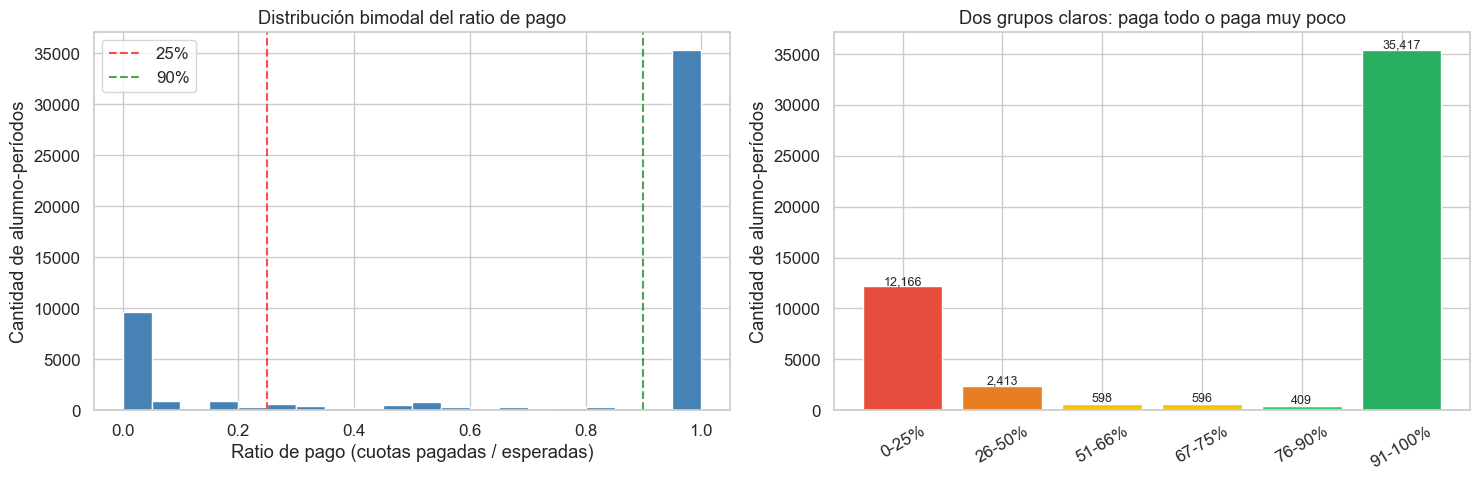

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Histograma del ratio de pago
axes[0].hist(pago_por_alumno_periodo['ratio_pago'], bins=20, color='steelblue', edgecolor='white')
axes[0].axvline(x=0.25, color='red', linestyle='--', alpha=0.7, label='25%')
axes[0].axvline(x=0.90, color='green', linestyle='--', alpha=0.7, label='90%')
axes[0].set_xlabel('Ratio de pago (cuotas pagadas / esperadas)')
axes[0].set_ylabel('Cantidad de alumno-períodos')
axes[0].set_title('Distribución bimodal del ratio de pago')
axes[0].legend()

# Gráfico 2: Barras por rango
rango_counts = pago_por_alumno_periodo['rango_ratio'].value_counts().sort_index()
colors = ['#e74c3c', '#e67e22', '#f1c40f', '#f1c40f', '#2ecc71', '#27ae60']
axes[1].bar(range(len(rango_counts)), rango_counts.values, color=colors, edgecolor='white')
axes[1].set_xticks(range(len(rango_counts)))
axes[1].set_xticklabels(rango_counts.index, rotation=30)
axes[1].set_ylabel('Cantidad de alumno-períodos')
axes[1].set_title('Dos grupos claros: paga todo o paga muy poco')
for i, v in enumerate(rango_counts.values):
    axes[1].text(i, v + 200, f'{v:,}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
print('=== Alumnos que pagaron 8+ cuotas de 12 ===')
pagaron_suficiente = pago_por_alumno_periodo[
    (pago_por_alumno_periodo['cuotas_esperadas'] >= 10) &
    (pago_por_alumno_periodo['cuotas_pagadas'] >= 8)
]
print(f'Alumno-períodos con 8+ cuotas pagadas de 10+: {len(pagaron_suficiente):,}')
print(f'Total alumno-períodos: {len(pago_por_alumno_periodo):,}')
print(f'Proporción: {len(pagaron_suficiente)/len(pago_por_alumno_periodo)*100:.1f}%')

print(f'\n=== Alumnos que no pagaron NINGUNA cuota ===')
no_pagaron_nada = pago_por_alumno_periodo[pago_por_alumno_periodo['cuotas_pagadas'] == 0]
print(f'Alumno-períodos con 0 cuotas pagadas: {len(no_pagaron_nada):,}')
print(f'Proporción: {len(no_pagaron_nada)/len(pago_por_alumno_periodo)*100:.1f}%')

=== Alumnos que pagaron 8+ cuotas de 12 ===
Alumno-períodos con 8+ cuotas pagadas de 10+: 11,826
Total alumno-períodos: 51,599
Proporción: 22.9%

=== Alumnos que no pagaron NINGUNA cuota ===
Alumno-períodos con 0 cuotas pagadas: 9,665
Proporción: 18.7%


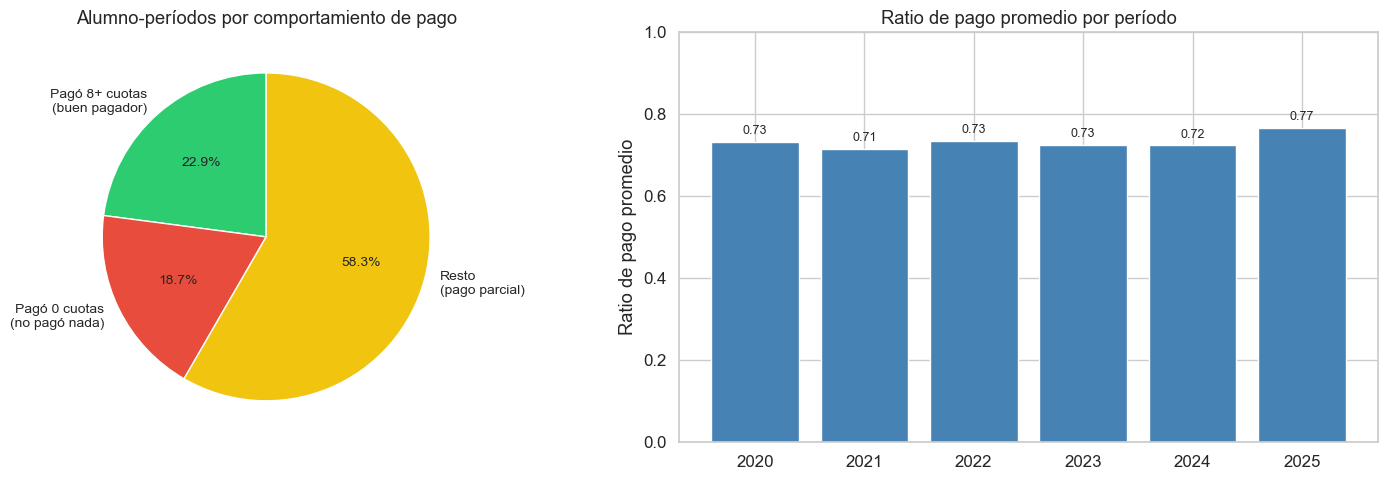

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico: alumnos que pagaron 8+ de 12 vs el resto
labels_pie = ['Pagó 8+ cuotas\n(buen pagador)', 'Pagó 0 cuotas\n(no pagó nada)', 'Resto\n(pago parcial)']
n_total_ap = len(pago_por_alumno_periodo)
n_8plus = len(pago_por_alumno_periodo[
    (pago_por_alumno_periodo['cuotas_esperadas'] >= 10) & (pago_por_alumno_periodo['cuotas_pagadas'] >= 8)
])
n_zero = len(pago_por_alumno_periodo[pago_por_alumno_periodo['cuotas_pagadas'] == 0])
n_resto = n_total_ap - n_8plus - n_zero

axes[0].pie([n_8plus, n_zero, n_resto],
            labels=labels_pie, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c', '#f1c40f'],
            startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Alumno-períodos por comportamiento de pago')

# Gráfico: ratio de pago promedio por período
ratio_por_periodo = pago_por_alumno_periodo.groupby(
    pago_por_alumno_periodo.merge(df[['id_alumno', 'periodo', 'contexto_temporal']].drop_duplicates(),
                                   on=['id_alumno', 'periodo'])['contexto_temporal']
)['ratio_pago'].mean()

ratio_anual = pago_por_alumno_periodo.merge(
    df[['id_alumno', 'periodo']].drop_duplicates(), on=['id_alumno', 'periodo']
).groupby('periodo')['ratio_pago'].mean()

axes[1].bar(ratio_anual.index.astype(str), ratio_anual.values, color='steelblue', edgecolor='white')
axes[1].set_ylabel('Ratio de pago promedio')
axes[1].set_title('Ratio de pago promedio por período')
axes[1].set_ylim(0, 1)
for i, (yr, val) in enumerate(zip(ratio_anual.index, ratio_anual.values)):
    axes[1].text(i, val + 0.02, f'{val:.2f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

### 7.2 Patrón temporal de pagos dentro del período

Analizar si los alumnos pagan las primeras cuotas y dejan de pagar hacia el final (patrón de abandono/egreso).

=== Tasa de pago por número de cuota ===
 nro_cuota  total  pagaron  tasa_pago
         1   8337     4067      48.78
         2  27790    18992      68.34
         3  27981    18319      65.47
         4  28056    17627      62.83
         5  28104    17080      60.77
         6  28191    16676      59.15
         7  52734    39877      75.62
         8  54083    39759      73.51
         9  54108    39231      72.50
        10  54139    38646      71.38
        11  44190    31132      70.45
        12  44208    30949      70.01


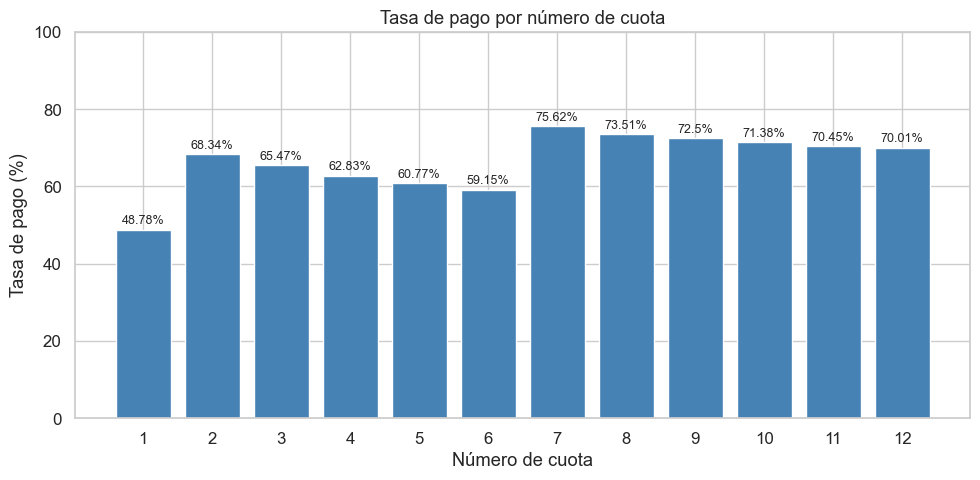

In [15]:
tasa_pago_por_cuota = df.groupby('nro_cuota').agg(
    total=('fecha_pago', 'size'),
    pagaron=('fecha_pago', lambda x: x.notna().sum())
).reset_index()
tasa_pago_por_cuota['tasa_pago'] = (tasa_pago_por_cuota['pagaron'] / tasa_pago_por_cuota['total'] * 100).round(2)

print('=== Tasa de pago por número de cuota ===')
print(tasa_pago_por_cuota.to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(tasa_pago_por_cuota['nro_cuota'], tasa_pago_por_cuota['tasa_pago'], color='steelblue')
ax.set_xlabel('Número de cuota')
ax.set_ylabel('Tasa de pago (%)')
ax.set_title('Tasa de pago por número de cuota')
ax.set_xticks(range(1, 13))
ax.set_ylim(0, 100)
for i, row in tasa_pago_por_cuota.iterrows():
    ax.text(row['nro_cuota'], row['tasa_pago'] + 1.5, f"{row['tasa_pago']}%", ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 7.3 Análisis de "sin_pago": ¿mora real o abandono?

Un porcentaje alto de `sin_pago` puede no ser mora real sino alumnos que:
1. **Abandonaron la carrera** definitivamente.
2. **Abandonaron temporalmente** y retomaron años después (las cuotas del año de abandono no son mora).
3. **Egresaron antes de completar todas las cuotas** del período.

Para distinguir estos casos necesitamos dos datos adicionales de MySQL:
- `alumno.periodo` → año de ingreso del alumno.
- `egresado_titulo.cursos` → duración de la carrera en años.

In [16]:
import os
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

_env_path = Path.cwd().parent / '.env'
if _env_path.exists():
    load_dotenv(_env_path)
else:
    load_dotenv()

conn_str = (
    f"mysql+pymysql://{os.getenv('MYSQL_USER')}:{os.getenv('MYSQL_PASSWORD')}"
    f"@{os.getenv('MYSQL_HOST')}:{os.getenv('MYSQL_PORT', '3306')}/{os.getenv('MYSQL_DB')}"
    f"?connect_timeout=30"
)
engine = create_engine(conn_str)

with engine.connect() as conn:
    conn.execute(text('SELECT 1'))
print(f"Conexión OK → {os.getenv('MYSQL_DB')}")

Conexión OK → eUNSTAv3


In [17]:
# Año de ingreso por alumno (traer todos, filtrar después en Python)
q_ingreso = "SELECT id_alumno, periodo AS anio_ingreso FROM alumno"
df_ingreso = pd.read_sql(text(q_ingreso), engine)
print(f'Año de ingreso: {len(df_ingreso):,} alumnos totales en la tabla')
print(f'Columnas: {df_ingreso.columns.tolist()}')
print(df_ingreso.head())

# Duración de carrera por id_carrera + id_sede + id_facultad
q_duracion = """
SELECT id_carrera, id_sede, id_facultad, cursos AS duracion_anios
FROM egresado_titulo
WHERE cursos IS NOT NULL AND cursos > 0
GROUP BY id_carrera, id_sede, id_facultad, cursos
"""
df_duracion = pd.read_sql(text(q_duracion), engine)
print(f'\nDuración de carreras: {len(df_duracion):,} combinaciones carrera/sede/facultad')
print(f'\nDistribución de duración (años):')
print(df_duracion['duracion_anios'].value_counts().sort_index())

# Nombres de carrera desde oferta_educativa
q_carreras = "SELECT TRIM(id_carrera) AS id_carrera, TRIM(nombre) AS nombre_carrera FROM oferta_educativa"
df_carreras = pd.read_sql(text(q_carreras), engine)
print(f'\nNombres de carreras: {len(df_carreras):,} registros')
print(df_carreras.head())

engine.dispose()
print('\nConexión cerrada.')

Año de ingreso: 70,647 alumnos totales en la tabla
Columnas: ['id_alumno', 'anio_ingreso']
   id_alumno  anio_ingreso
0          1        1995.0
1          2        1991.0
2          3        1990.0
3          4        1992.0
4          5        1991.0

Duración de carreras: 207 combinaciones carrera/sede/facultad

Distribución de duración (años):
duracion_anios
1    13
2    52
3    41
4    55
5    45
6     1
Name: count, dtype: int64

Nombres de carreras: 174 registros
  id_carrera        nombre_carrera
0         00            SIN OFERTA
1         01  LIC.COMERCIALIZACION
2         02  ADM.EMPR.FINANCIERAS
3         03    LIC.RELAC.PUBLICAS
4         04   LIC.EN ADM.DE EMPR.

Conexión cerrada.


In [18]:
# Limpiar columnas de ejecuciones anteriores si existen
cols_drop = [c for c in ['anio_ingreso', 'duracion_anios', '_carrera', '_sede', '_fac',
                          'ultimo_periodo', 'tiene_brecha', 'es_antes_brecha',
                          'anios_cursados', 'excedio_duracion', 'n_periodos',
                          'subtipo_sin_pago'] if c in df.columns]
if cols_drop:
    df.drop(columns=cols_drop, inplace=True)
    print(f'Columnas limpiadas de ejecuciones previas: {cols_drop}')

n_antes_merge = len(df)

# Merge año de ingreso
df = df.merge(df_ingreso, on='id_alumno', how='left')
print(f'Nulos en anio_ingreso: {df["anio_ingreso"].isna().sum():,}')
assert len(df) == n_antes_merge, f'MERGE duplicó filas: {n_antes_merge} → {len(df)}'

# Preparar claves de join para duración de carrera
# egresado_titulo usa: id_carrera, id_sede, id_facultad
# nuestro df usa: id_carrera, id_sede_academica, id_facultad
df['_carrera'] = df['id_carrera'].astype(str).str.strip()
df['_sede'] = df['id_sede_academica'].astype(str).str.strip()
df['_fac'] = df['id_facultad'].astype(str).str.strip()

df_duracion['_carrera'] = df_duracion['id_carrera'].astype(str).str.strip()
df_duracion['_sede'] = df_duracion['id_sede'].astype(str).str.strip()
df_duracion['_fac'] = df_duracion['id_facultad'].astype(str).str.strip()

df = df.merge(
    df_duracion[['_carrera', '_sede', '_fac', 'duracion_anios']],
    on=['_carrera', '_sede', '_fac'],
    how='left'
)
df.drop(columns=['_carrera', '_sede', '_fac'], inplace=True)

print(f'Nulos en duracion_anios: {df["duracion_anios"].isna().sum():,} ({df["duracion_anios"].isna().mean()*100:.1f}%)')
print(f'Dataset con datos adicionales: {len(df):,} filas')

# Verificar que no se duplicaron filas
if len(df) != n_antes_merge:
    print(f'ADVERTENCIA: el merge generó {len(df) - n_antes_merge:,} filas extra (duplicados en egresado_titulo)')
    print('Eliminando duplicados...')
    df = df.drop_duplicates(subset=['id_alumno', 'periodo', 'nro_cuota'], keep='first')
    print(f'Filas después de dedup: {len(df):,}')

Nulos en anio_ingreso: 276
Nulos en duracion_anios: 451,921 (100.0%)
Dataset con datos adicionales: 451,921 filas


### 7.4 Detección de brechas (abandono temporal y retorno)

Un alumno que tiene categoría arancelaria en 2020 y 2021, luego nada en 2022, y vuelve en 2023, presenta una **brecha**. Las cuotas sin pago del último período antes de la brecha (2021) probablemente son abandono temporal, no mora real.

In [19]:
# Períodos por alumno (ordenados)
periodos_alumno = (
    df.groupby('id_alumno')['periodo']
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
    .rename(columns={'periodo': 'periodos'})
)

def detectar_brechas(periodos):
    """Detecta años faltantes entre períodos consecutivos."""
    brechas = []
    for i in range(1, len(periodos)):
        gap = periodos[i] - periodos[i-1]
        if gap > 1:
            brechas.append({
                'periodo_antes': periodos[i-1],
                'periodo_retorno': periodos[i],
                'anios_brecha': gap - 1
            })
    return brechas

periodos_alumno['brechas'] = periodos_alumno['periodos'].apply(detectar_brechas)
periodos_alumno['tiene_brecha'] = periodos_alumno['brechas'].apply(lambda x: len(x) > 0)
periodos_alumno['n_brechas'] = periodos_alumno['brechas'].apply(len)
periodos_alumno['ultimo_periodo'] = periodos_alumno['periodos'].apply(max)
periodos_alumno['primer_periodo'] = periodos_alumno['periodos'].apply(min)
periodos_alumno['n_periodos'] = periodos_alumno['periodos'].apply(len)

print(f'=== Análisis de brechas por alumno ===')
print(f'Alumnos totales:       {len(periodos_alumno):,}')
print(f'Alumnos CON brecha:    {periodos_alumno["tiene_brecha"].sum():,} ({periodos_alumno["tiene_brecha"].mean()*100:.1f}%)')
print(f'Alumnos SIN brecha:    {(~periodos_alumno["tiene_brecha"]).sum():,}')

print(f'\n=== Distribución de cantidad de brechas ===')
print(periodos_alumno['n_brechas'].value_counts().sort_index())

=== Análisis de brechas por alumno ===
Alumnos totales:       24,148
Alumnos CON brecha:    181 (0.7%)
Alumnos SIN brecha:    23,967

=== Distribución de cantidad de brechas ===
n_brechas
0    23967
1      179
2        2
Name: count, dtype: int64


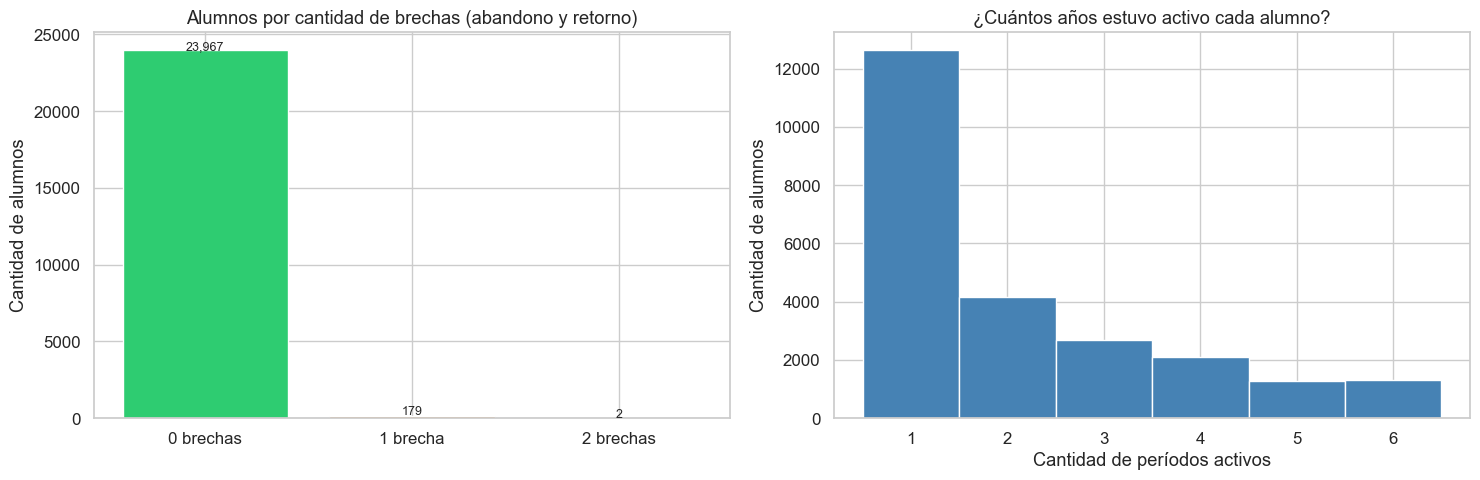

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Alumnos con y sin brechas
brecha_counts = periodos_alumno['n_brechas'].value_counts().sort_index()
labels_b = [f'{n} brecha{"s" if n != 1 else ""}' for n in brecha_counts.index]
colors_b = ['#2ecc71'] + ['#e67e22'] * (len(brecha_counts) - 1)
axes[0].bar(labels_b, brecha_counts.values, color=colors_b, edgecolor='white')
axes[0].set_ylabel('Cantidad de alumnos')
axes[0].set_title('Alumnos por cantidad de brechas (abandono y retorno)')
for i, v in enumerate(brecha_counts.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=9)

# Gráfico 2: Distribución de períodos activos por alumno
axes[1].hist(periodos_alumno['n_periodos'], bins=range(1, periodos_alumno['n_periodos'].max() + 2),
             color='steelblue', edgecolor='white', align='left')
axes[1].set_xlabel('Cantidad de períodos activos')
axes[1].set_ylabel('Cantidad de alumnos')
axes[1].set_title('¿Cuántos años estuvo activo cada alumno?')
axes[1].set_xticks(range(1, periodos_alumno['n_periodos'].max() + 1))

plt.tight_layout()
plt.show()

### 7.5 Clasificación de "sin_pago" en subcategorías

Combinando año de ingreso, duración de carrera, último período y brechas, clasificamos cada cuota `sin_pago`:

| Subcategoría | Lógica |
|---|---|
| `abandono_definitivo` | Último período del alumno < período actual Y (años cursados < duración carrera) Y sin brecha posterior |
| `abandono_temporal` | Cuota pertenece a un período justo antes de una brecha (el alumno volvió después) |
| `excedio_duracion` | Años desde ingreso > duración de la carrera (posible egreso no registrado o rezago extremo) |
| `sin_pago_real` | No encaja en ninguno de los anteriores → mora genuina |

In [21]:
# Expandir brechas: para cada alumno con brecha, listar el período justo antes de cada brecha
periodos_antes_brecha = []
for _, row in periodos_alumno[periodos_alumno['tiene_brecha']].iterrows():
    for b in row['brechas']:
        periodos_antes_brecha.append({
            'id_alumno': row['id_alumno'],
            'periodo_antes_brecha': b['periodo_antes']
        })

df_brechas = pd.DataFrame(periodos_antes_brecha)
print(f'Períodos antes de brecha identificados: {len(df_brechas):,}')

# Merge info del alumno al dataset
df = df.merge(
    periodos_alumno[['id_alumno', 'ultimo_periodo', 'tiene_brecha', 'n_periodos']],
    on='id_alumno', how='left'
)

# Marcar cuotas en período justo antes de una brecha
if len(df_brechas) > 0:
    df_brechas['es_antes_brecha'] = True
    df = df.merge(
        df_brechas.rename(columns={'periodo_antes_brecha': 'periodo'}),
        on=['id_alumno', 'periodo'],
        how='left'
    )
    df['es_antes_brecha'] = df['es_antes_brecha'].fillna(False)
else:
    df['es_antes_brecha'] = False

# Años cursados y excedido
df['anios_cursados'] = df['periodo'] - df['anio_ingreso']
df['excedio_duracion'] = (df['anios_cursados'] > df['duracion_anios']).fillna(False)

PERIODO_ACTUAL = 2026

print(f'Columnas agregadas: ultimo_periodo, tiene_brecha, es_antes_brecha, anios_cursados, excedio_duracion')

Períodos antes de brecha identificados: 183
Columnas agregadas: ultimo_periodo, tiene_brecha, es_antes_brecha, anios_cursados, excedio_duracion


C:\Users\Chelo\AppData\Local\Temp\ipykernel_12884\1753997544.py:27: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['es_antes_brecha'] = df['es_antes_brecha'].fillna(False)


In [22]:
mask_sin_pago = df['tipo_mora'] == 'sin_pago'

def clasificar_sin_pago(row):
    if row['tipo_mora'] != 'sin_pago':
        return row['tipo_mora']

    # Caso 1: cuota de un período antes de una brecha → abandono temporal
    if row['es_antes_brecha']:
        return 'abandono_temporal'

    # Caso 2: alumno excedió la duración de la carrera
    if row['excedio_duracion']:
        return 'excedio_duracion'

    # Caso 3: último período del alumno < período actual y no hay brecha posterior → abandono definitivo
    if row['ultimo_periodo'] < PERIODO_ACTUAL and row['periodo'] == row['ultimo_periodo']:
        return 'abandono_definitivo'

    # Caso 4: mora genuina
    return 'sin_pago_real'

df['subtipo_sin_pago'] = df.apply(clasificar_sin_pago, axis=1)

print('=== Descomposición del "sin_pago" ===\n')
orden_sub = ['en_termino', 'mora_leve', 'mora_media', 'mora_grave',
             'sin_pago_real', 'abandono_definitivo', 'abandono_temporal', 'excedio_duracion']
sub_dist = df['subtipo_sin_pago'].value_counts().reindex(orden_sub).dropna()
sub_pct = (sub_dist / len(df) * 100).round(2)
print(pd.DataFrame({'cantidad': sub_dist.astype(int), 'porcentaje': sub_pct}))

print(f'\n=== Solo filas que eran "sin_pago" original ===')
solo_sp = df[mask_sin_pago]['subtipo_sin_pago'].value_counts()
solo_sp_pct = (solo_sp / mask_sin_pago.sum() * 100).round(2)
print(pd.DataFrame({'cantidad': solo_sp, 'pct_del_sin_pago': solo_sp_pct}))

=== Descomposición del "sin_pago" ===

                     cantidad  porcentaje
subtipo_sin_pago                         
en_termino              94299       20.87
mora_leve              157054       34.75
mora_media              13608        3.01
mora_grave              47394       10.49
sin_pago_real           34900        7.72
abandono_definitivo    103879       22.99
abandono_temporal         787        0.17

=== Solo filas que eran "sin_pago" original ===
                     cantidad  pct_del_sin_pago
subtipo_sin_pago                               
abandono_definitivo    103879             74.43
sin_pago_real           34900             25.01
abandono_temporal         787              0.56


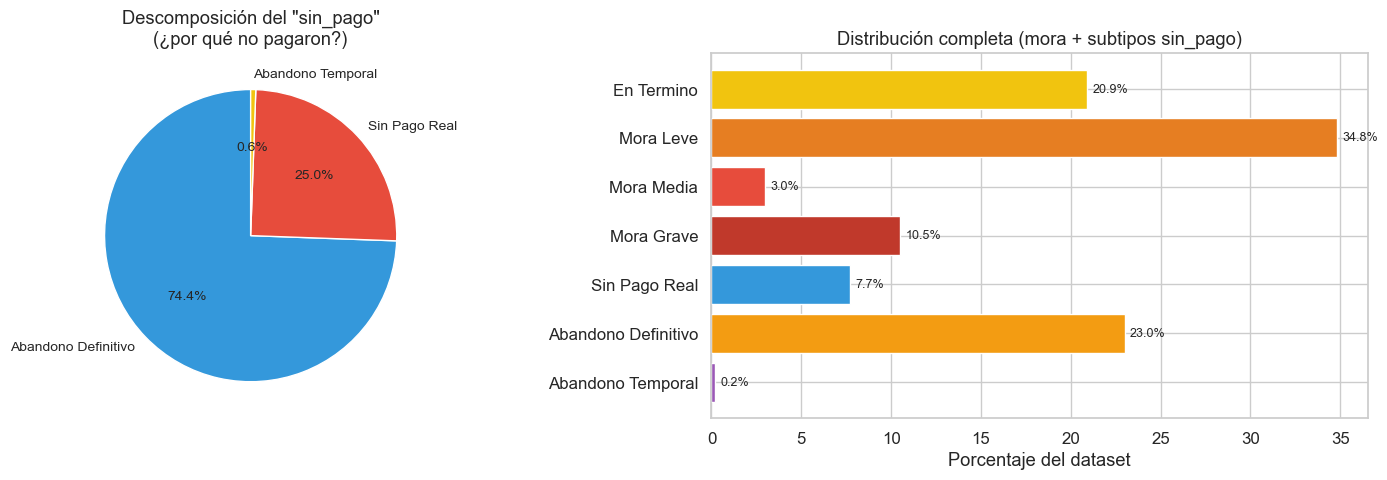

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Descomposición del sin_pago (torta)
solo_sp = df[mask_sin_pago]['subtipo_sin_pago'].value_counts()
colors_sp = {'sin_pago_real': '#e74c3c', 'abandono_definitivo': '#3498db',
             'abandono_temporal': '#f1c40f', 'excedio_duracion': '#9b59b6'}
sp_labels = [s.replace('_', ' ').title() for s in solo_sp.index]
sp_colors = [colors_sp.get(s, '#95a5a6') for s in solo_sp.index]

axes[0].pie(solo_sp.values, labels=sp_labels, autopct='%1.1f%%',
            colors=sp_colors, startangle=90, textprops={'fontsize': 10})
axes[0].set_title('Descomposición del "sin_pago"\n(¿por qué no pagaron?)')

# Gráfico 2: Distribución completa con subtipos (barras horizontales)
orden_completo = ['en_termino', 'mora_leve', 'mora_media', 'mora_grave',
                  'sin_pago_real', 'abandono_definitivo', 'abandono_temporal', 'excedio_duracion']
full_dist = df['subtipo_sin_pago'].value_counts().reindex(orden_completo).dropna()
full_pct = (full_dist / len(df) * 100).round(1)

colors_full = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#3498db', '#f39c12', '#9b59b6']
labels_full = [s.replace('_', ' ').title() for s in full_dist.index]

bars = axes[1].barh(labels_full[::-1], full_pct.values[::-1], color=colors_full[::-1], edgecolor='white')
axes[1].set_xlabel('Porcentaje del dataset')
axes[1].set_title('Distribución completa (mora + subtipos sin_pago)')
for bar, pct in zip(bars, full_pct.values[::-1]):
    axes[1].text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                 f'{pct}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [24]:
print('=== Impacto en las tasas de mora ===\n')

# Mora considerando solo sin_pago_real como mora verdadera
mora_ajustada = df['subtipo_sin_pago'].isin(['mora_leve', 'mora_media', 'mora_grave', 'sin_pago_real'])
mora_original = df['target_no_pago'] == 1

print(f'Tasa de mora original (target_no_pago):  {mora_original.mean()*100:.1f}%')
print(f'Tasa de mora ajustada (sin abandonos):    {mora_ajustada.mean()*100:.1f}%')
print(f'Reducción:                                {(mora_original.mean() - mora_ajustada.mean())*100:.1f} puntos porcentuales')

print(f'\n=== Alumnos con brecha: detalle ===')
alumnos_con_brecha = periodos_alumno[periodos_alumno['tiene_brecha']]
print(f'Alumnos que abandonaron y retomaron: {len(alumnos_con_brecha):,}')
if len(alumnos_con_brecha) > 0:
    print(f'\nEjemplos de alumnos con brecha (periodos cursados):')
    for _, row in alumnos_con_brecha.head(10).iterrows():
        brechas_str = ', '.join([f"{b['periodo_antes']}->{b['periodo_retorno']} ({b['anios_brecha']}a)" for b in row['brechas']])
        print(f"  Alumno {row['id_alumno']}: períodos {row['periodos']} | brechas: {brechas_str}")

=== Impacto en las tasas de mora ===

Tasa de mora original (target_no_pago):  72.1%
Tasa de mora ajustada (sin abandonos):    56.0%
Reducción:                                16.1 puntos porcentuales

=== Alumnos con brecha: detalle ===
Alumnos que abandonaron y retomaron: 181

Ejemplos de alumnos con brecha (periodos cursados):
  Alumno 2154: períodos [2020, 2021, 2022, 2025] | brechas: 2022->2025 (2a)
  Alumno 5216: períodos [2020, 2021, 2023] | brechas: 2021->2023 (1a)
  Alumno 9097: períodos [2022, 2025] | brechas: 2022->2025 (2a)
  Alumno 13943: períodos [2020, 2022] | brechas: 2020->2022 (1a)
  Alumno 16292: períodos [2020, 2021, 2022, 2024] | brechas: 2022->2024 (1a)
  Alumno 18041: períodos [2020, 2021, 2023] | brechas: 2021->2023 (1a)
  Alumno 1000687: períodos [2022, 2024] | brechas: 2022->2024 (1a)
  Alumno 1007133: períodos [2021, 2023] | brechas: 2021->2023 (1a)
  Alumno 1007209: períodos [2020, 2023] | brechas: 2020->2023 (2a)
  Alumno 1009258: períodos [2020, 2023] | bre

C:\Users\Chelo\AppData\Local\Temp\ipykernel_12884\3838950997.py:20: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mora_real_periodo = df.groupby('periodo').apply(


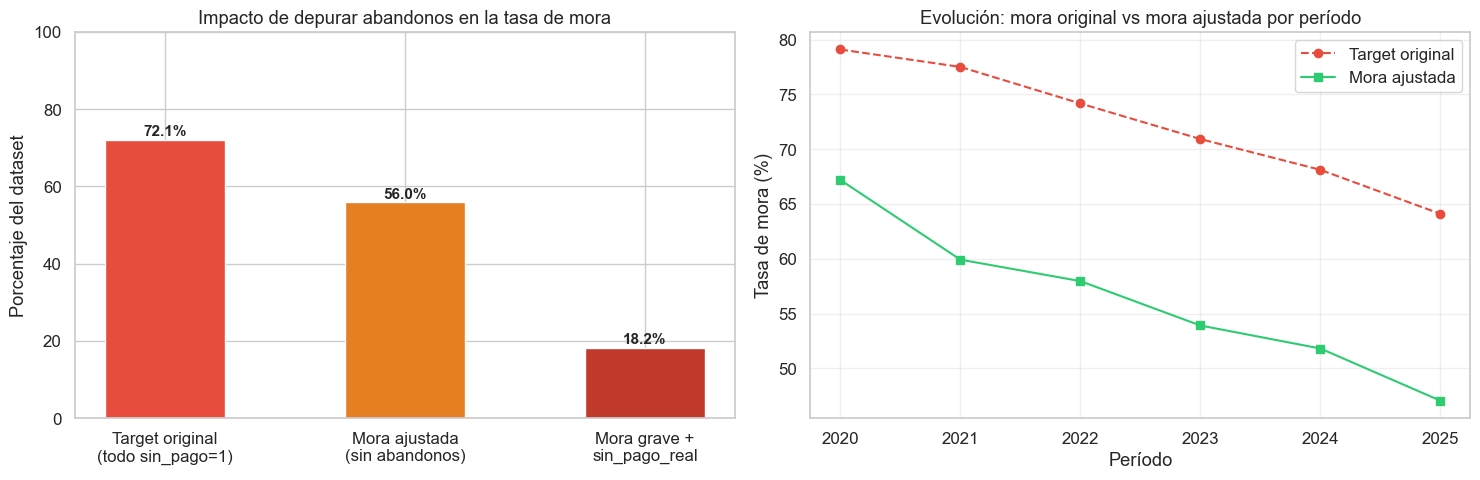

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Gráfico 1: Comparación de tasas de mora (original vs ajustada)
mora_original_pct = (df['target_no_pago'] == 1).mean() * 100
mora_ajustada_pct = df['subtipo_sin_pago'].isin(['mora_leve', 'mora_media', 'mora_grave', 'sin_pago_real']).mean() * 100
mora_solo_real_pct = df['subtipo_sin_pago'].isin(['mora_grave', 'sin_pago_real']).mean() * 100

bars = axes[0].bar(
    ['Target original\n(todo sin_pago=1)', 'Mora ajustada\n(sin abandonos)', 'Mora grave +\nsin_pago_real'],
    [mora_original_pct, mora_ajustada_pct, mora_solo_real_pct],
    color=['#e74c3c', '#e67e22', '#c0392b'], edgecolor='white', width=0.5
)
axes[0].set_ylabel('Porcentaje del dataset')
axes[0].set_title('Impacto de depurar abandonos en la tasa de mora')
axes[0].set_ylim(0, 100)
for bar, pct in zip(bars, [mora_original_pct, mora_ajustada_pct, mora_solo_real_pct]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f'{pct:.1f}%', ha='center', fontsize=11, fontweight='bold')

# Gráfico 2: Evolución de mora real por período
mora_real_periodo = df.groupby('periodo').apply(
    lambda x: x['subtipo_sin_pago'].isin(['mora_leve', 'mora_media', 'mora_grave', 'sin_pago_real']).mean() * 100
)
mora_orig_periodo = df.groupby('periodo')['target_no_pago'].mean() * 100

axes[1].plot(mora_orig_periodo.index, mora_orig_periodo.values, 'o--', color='#e74c3c', label='Target original', markersize=6)
axes[1].plot(mora_real_periodo.index, mora_real_periodo.values, 's-', color='#2ecc71', label='Mora ajustada', markersize=6)
axes[1].set_xlabel('Período')
axes[1].set_ylabel('Tasa de mora (%)')
axes[1].set_title('Evolución: mora original vs mora ajustada por período')
axes[1].legend()
axes[1].set_xticks(mora_orig_periodo.index)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Visualizaciones del EDA

=== Distribución detallada por período ===


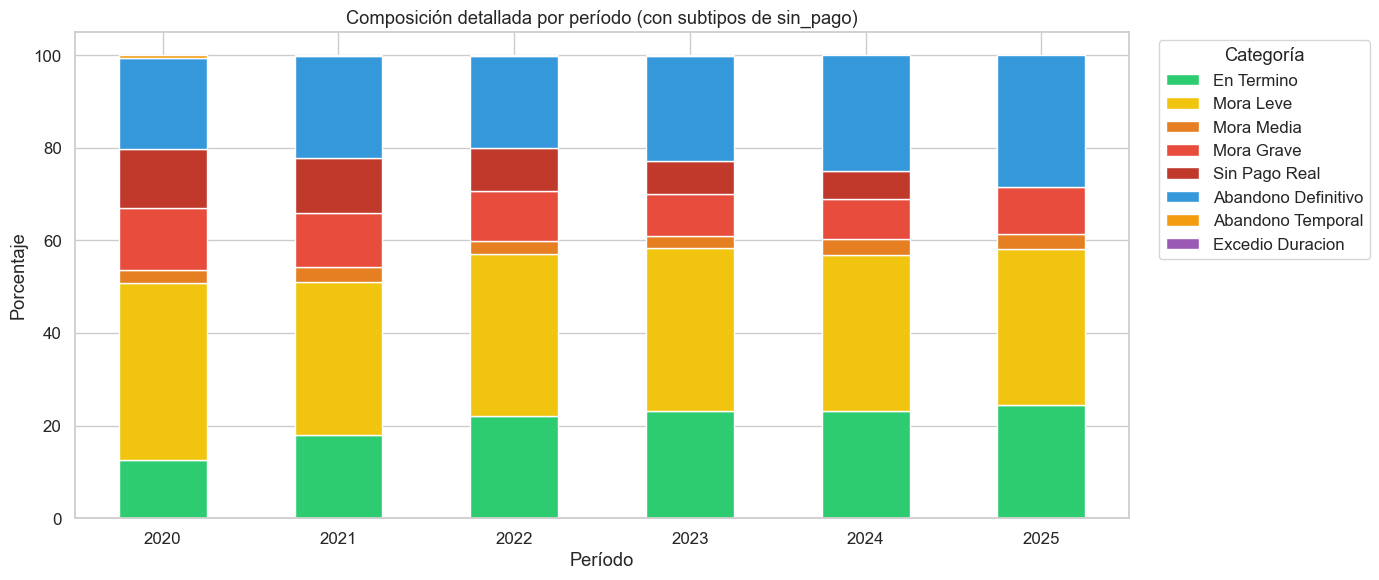

subtipo_sin_pago  en_termino  mora_leve  mora_media  mora_grave  sin_pago_real  abandono_definitivo  abandono_temporal  excedio_duracion
periodo                                                                                                                                 
2020                   12.57      38.28        2.83       13.27          12.82                19.67               0.57               0.0
2021                   17.91      33.03        3.23       11.75          11.91                21.90               0.26               0.0
2022                   21.99      35.06        2.82       10.80           9.28                19.83               0.22               0.0
2023                   23.19      35.10        2.65        9.12           7.05                22.80               0.09               0.0
2024                   23.16      33.78        3.31        8.79           5.94                25.02               0.00               0.0
2025                   24.45      33.65  

In [26]:
print('=== Distribución detallada por período ===')
orden_cols = ['en_termino', 'mora_leve', 'mora_media', 'mora_grave',
              'sin_pago_real', 'abandono_definitivo', 'abandono_temporal', 'excedio_duracion']
colores = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c', '#c0392b', '#3498db', '#f39c12', '#9b59b6']

cross_periodo = pd.crosstab(df['periodo'], df['subtipo_sin_pago'], normalize='index').mul(100).round(2)
cross_periodo = cross_periodo.reindex(columns=orden_cols).fillna(0)

fig, ax = plt.subplots(figsize=(14, 6))
cross_periodo.plot(kind='bar', stacked=True, ax=ax, color=colores)
ax.set_ylabel('Porcentaje')
ax.set_title('Composición detallada por período (con subtipos de sin_pago)')
ax.legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left',
          labels=[s.replace('_', ' ').title() for s in orden_cols])
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_xlabel('Período')
plt.tight_layout()
plt.show()

print(cross_periodo)

=== Mora por contexto temporal (detallado) ===
subtipo_sin_pago   en_termino  mora_leve  mora_media  mora_grave  sin_pago_real  abandono_definitivo  abandono_temporal  excedio_duracion
contexto_temporal                                                                                                                        
pandemia                15.38      35.53        3.04       12.47          12.34                20.84               0.41               0.0
post_pandemia           23.16      34.43        3.00        9.66           5.79                23.88               0.08               0.0

=== Mora por sexo (detallado) ===


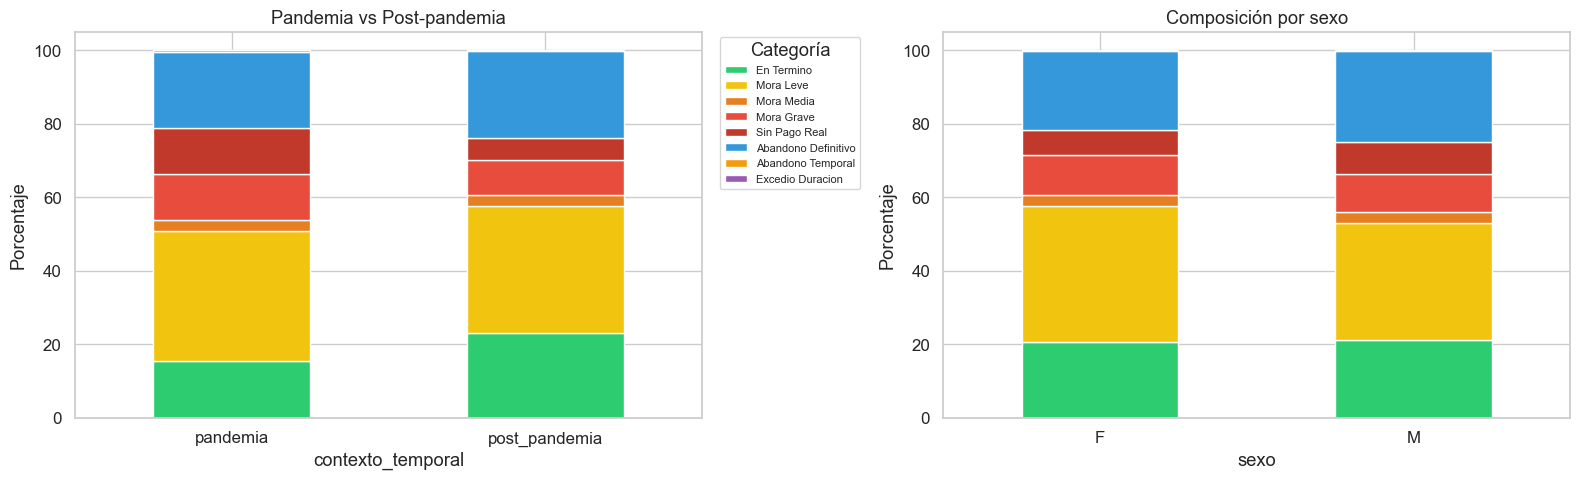

subtipo_sin_pago  en_termino  mora_leve  mora_media  mora_grave  sin_pago_real  abandono_definitivo  abandono_temporal  excedio_duracion
sexo                                                                                                                                    
F                      20.74      36.97        3.04       10.63           6.91                21.63               0.08               0.0
M                      21.07      31.95        2.97       10.32           8.80                24.59               0.30               0.0


In [27]:
print('=== Mora por contexto temporal (detallado) ===')
cross_ctx = pd.crosstab(df['contexto_temporal'], df['subtipo_sin_pago'], normalize='index').mul(100).round(2)
cross_ctx = cross_ctx.reindex(columns=orden_cols).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

cross_ctx.plot(kind='bar', stacked=True, ax=axes[0], color=colores)
axes[0].set_ylabel('Porcentaje')
axes[0].set_title('Pandemia vs Post-pandemia')
axes[0].legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=8,
               labels=[s.replace('_', ' ').title() for s in orden_cols])
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)

print(cross_ctx)

print(f'\n=== Mora por sexo (detallado) ===')
cross_sexo = pd.crosstab(df['sexo'], df['subtipo_sin_pago'], normalize='index').mul(100).round(2)
cross_sexo = cross_sexo.reindex(columns=orden_cols).fillna(0)

cross_sexo.plot(kind='bar', stacked=True, ax=axes[1], color=colores)
axes[1].set_ylabel('Porcentaje')
axes[1].set_title('Composición por sexo')
axes[1].legend_.remove()
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

print(cross_sexo)

=== Distribución de edad al vencer ===


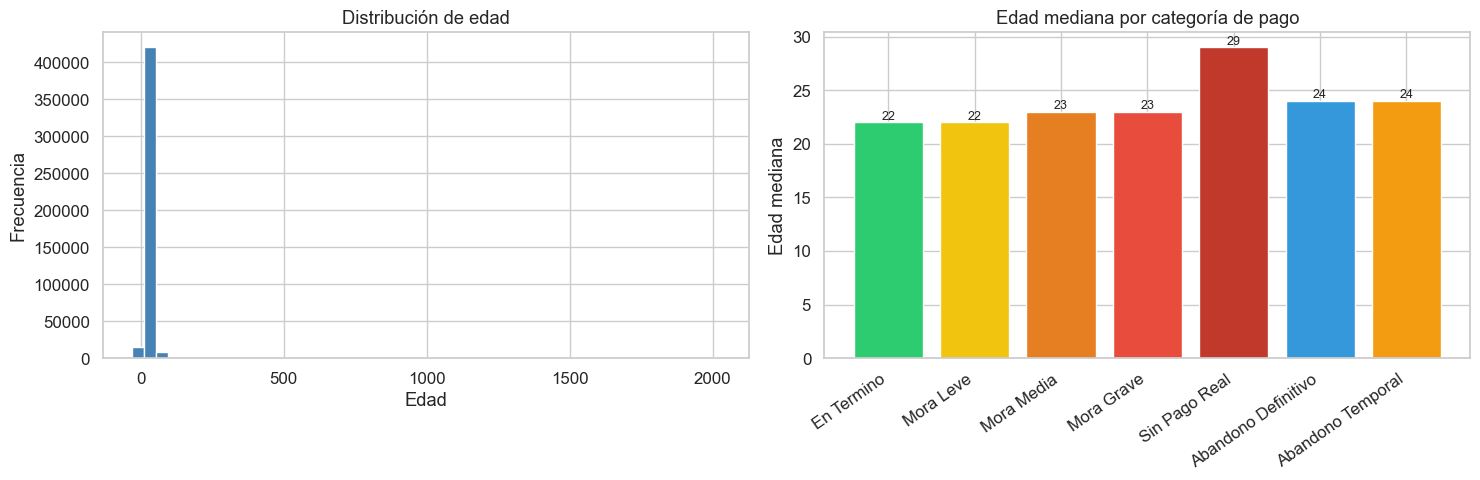

In [28]:
print('=== Distribución de edad al vencer ===')
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['edad_al_vencer'].hist(bins=50, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_xlabel('Edad')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title('Distribución de edad')

edad_por_subtipo = df.groupby('subtipo_sin_pago')['edad_al_vencer'].median().reindex(orden_cols).dropna()
bars = axes[1].bar(range(len(edad_por_subtipo)),
                    edad_por_subtipo.values,
                    color=[colores[orden_cols.index(c)] for c in edad_por_subtipo.index],
                    edgecolor='white')
axes[1].set_xticks(range(len(edad_por_subtipo)))
axes[1].set_xticklabels([s.replace('_', ' ').title() for s in edad_por_subtipo.index], rotation=35, ha='right')
axes[1].set_ylabel('Edad mediana')
axes[1].set_title('Edad mediana por categoría de pago')
for bar, val in zip(bars, edad_por_subtipo.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3, f'{val:.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

=== Top 10 carreras por volumen ===


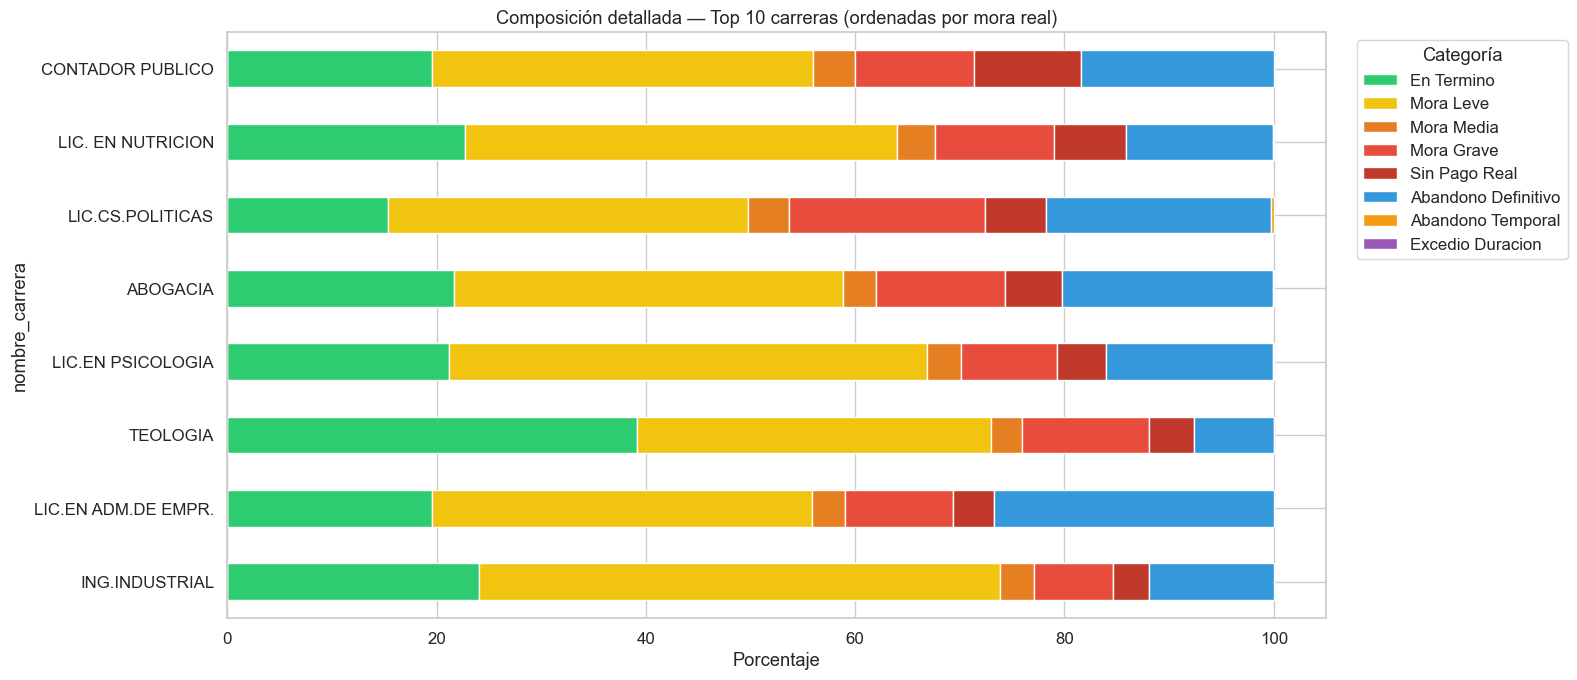


=== Tasa de mora REAL por carrera (solo sin_pago_real + mora_grave) ===
nombre_carrera
LIC.CS.POLITICAS       24.5
CONTADOR PUBLICO       21.6
LIC. EN NUTRICION      18.2
ABOGACIA               17.8
TEOLOGIA               16.4
LIC.EN ADM.DE EMPR.    14.2
LIC.EN PSICOLOGIA      13.9
ING.INDUSTRIAL         11.0
dtype: float64


C:\Users\Chelo\AppData\Local\Temp\ipykernel_12884\2839686016.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  mora_real_carrera = df_top.groupby('nombre_carrera').apply(


In [29]:
print('=== Top 10 carreras por volumen ===')
top_carreras = df['id_carrera'].value_counts().head(10).index
df_top = df[df['id_carrera'].isin(top_carreras)].copy()

# Mapear id_carrera a nombre
mapa_carreras = df_carreras.drop_duplicates('id_carrera').set_index('id_carrera')['nombre_carrera']
df_top['nombre_carrera'] = df_top['id_carrera'].astype(str).str.strip().map(mapa_carreras)
df_top['nombre_carrera'] = df_top['nombre_carrera'].fillna('ID: ' + df_top['id_carrera'].astype(str))

cross_carrera = pd.crosstab(df_top['nombre_carrera'], df_top['subtipo_sin_pago'], normalize='index').mul(100).round(2)
cross_carrera = cross_carrera.reindex(columns=orden_cols).fillna(0)
cross_carrera = cross_carrera.sort_values('sin_pago_real', ascending=True)

fig, ax = plt.subplots(figsize=(16, 7))
cross_carrera.plot(kind='barh', stacked=True, ax=ax, color=colores)
ax.set_xlabel('Porcentaje')
ax.set_title('Composición detallada — Top 10 carreras (ordenadas por mora real)')
ax.legend(title='Categoría', bbox_to_anchor=(1.02, 1), loc='upper left',
          labels=[s.replace('_', ' ').title() for s in orden_cols])
plt.tight_layout()
plt.show()

print('\n=== Tasa de mora REAL por carrera (solo sin_pago_real + mora_grave) ===')
mora_real_carrera = df_top.groupby('nombre_carrera').apply(
    lambda x: x['subtipo_sin_pago'].isin(['sin_pago_real', 'mora_grave']).mean() * 100
).sort_values(ascending=False).round(1)
print(mora_real_carrera)

## 9. Feature Engineering

### Features derivadas a nivel fila (alumno × cuota)

In [30]:
df['mes_vencimiento'] = df['fecha_vencimiento'].dt.month
df['semestre'] = np.where(df['nro_cuota'] <= 6, 1, 2)
df['es_pandemia'] = (df['contexto_temporal'] == 'pandemia').astype(int)

# Features derivadas del análisis de sección 7
df['anios_en_carrera'] = df['periodo'] - df['anio_ingreso']
df['pct_avance_carrera'] = (df['anios_en_carrera'] / df['duracion_anios']).clip(0, 2).round(4)
df['es_ultimo_periodo'] = (df['periodo'] == df['ultimo_periodo']).astype(int)
df['tiene_brecha'] = df['tiene_brecha'].astype(int)

# Target binario para mora genuina (excluyendo abandonos)
df['es_mora_genuina'] = df['subtipo_sin_pago'].isin(
    ['mora_leve', 'mora_media', 'mora_grave', 'sin_pago_real']
).astype(int)

features_nuevas = ['mes_vencimiento', 'semestre', 'es_pandemia', 'anios_en_carrera',
                   'pct_avance_carrera', 'es_ultimo_periodo', 'tiene_brecha', 'es_mora_genuina']
print(f'Features creadas: {features_nuevas}')
df[features_nuevas].describe().round(3)

Features creadas: ['mes_vencimiento', 'semestre', 'es_pandemia', 'anios_en_carrera', 'pct_avance_carrera', 'es_ultimo_periodo', 'tiene_brecha', 'es_mora_genuina']


,mes_vencimiento,semestre,es_pandemia,anios_en_carrera,pct_avance_carrera,es_ultimo_periodo,tiene_brecha,es_mora_genuina
count,451921.000,451921.000,451921.000,451645.000,0.0,451921.000,451921.000,451921.000
mean,7.213,1.671,0.294,24.124,NaN,0.444,0.015,0.560
std,3.687,0.470,0.456,206.880,NaN,0.497,0.120,0.496
min,1.000,1.000,0.000,-3.000,NaN,0.000,0.000,0.000
25%,4.000,1.000,0.000,0.000,NaN,0.000,0.000,0.000
50%,8.000,2.000,0.000,1.000,NaN,0.000,0.000,1.000
75%,10.000,2.000,1.000,4.000,NaN,1.000,0.000,1.000
max,12.000,2.000,1.000,2025.000,NaN,1.000,1.000,1.000


### 9.1 Historial de mora del alumno (períodos anteriores)

Para cada alumno × período, calcula métricas de comportamiento de pago en períodos anteriores. Este es el predictor más potente esperado: el mejor predictor de mora futura es la mora pasada.

In [31]:
hist_alumno = df.sort_values(['id_alumno', 'periodo', 'nro_cuota']).copy()

pago_alumno_periodo = hist_alumno.groupby(['id_alumno', 'periodo']).agg(
    cuotas_esperadas=('nro_cuota', 'count'),
    cuotas_pagadas=('fecha_pago', lambda x: x.notna().sum()),
    cuotas_en_termino=('tipo_mora', lambda x: (x == 'en_termino').sum()),
    cuotas_mora_genuina=('es_mora_genuina', 'sum'),
    cuotas_sin_pago_real=('subtipo_sin_pago', lambda x: (x == 'sin_pago_real').sum()),
    dias_atraso_promedio=('dias_habiles_atraso', 'mean')
).reset_index()

pago_alumno_periodo['ratio_pago_periodo'] = (
    pago_alumno_periodo['cuotas_pagadas'] / pago_alumno_periodo['cuotas_esperadas']
).round(4)
pago_alumno_periodo['ratio_en_termino_periodo'] = (
    pago_alumno_periodo['cuotas_en_termino'] / pago_alumno_periodo['cuotas_esperadas']
).round(4)
pago_alumno_periodo['ratio_mora_genuina_periodo'] = (
    pago_alumno_periodo['cuotas_mora_genuina'] / pago_alumno_periodo['cuotas_esperadas']
).round(4)

print(f'Resumen alumno-período calculado: {len(pago_alumno_periodo):,} registros')
pago_alumno_periodo.head()

Resumen alumno-período calculado: 51,599 registros


,id_alumno,periodo,cuotas_esperadas,cuotas_pagadas,cuotas_en_termino,cuotas_mora_genuina,cuotas_sin_pago_real,dias_atraso_promedio,ratio_pago_periodo,ratio_en_termino_periodo,ratio_mora_genuina_periodo
0,66,2023,12,0,0,0,0,NaN,0.0,0.0,0.0
1,134,2020,12,0,0,0,0,NaN,0.0,0.0,0.0
2,138,2022,12,0,0,0,0,NaN,0.0,0.0,0.0
3,301,2021,12,0,0,0,0,NaN,0.0,0.0,0.0
4,327,2025,10,0,0,0,0,NaN,0.0,0.0,0.0


In [32]:
pago_alumno_periodo = pago_alumno_periodo.sort_values(['id_alumno', 'periodo'])

pago_alumno_periodo['hist_ratio_pago'] = (
    pago_alumno_periodo.groupby('id_alumno')['ratio_pago_periodo']
    .transform(lambda x: x.expanding().mean().shift(1))
)
pago_alumno_periodo['hist_ratio_en_termino'] = (
    pago_alumno_periodo.groupby('id_alumno')['ratio_en_termino_periodo']
    .transform(lambda x: x.expanding().mean().shift(1))
)
pago_alumno_periodo['hist_ratio_mora_genuina'] = (
    pago_alumno_periodo.groupby('id_alumno')['ratio_mora_genuina_periodo']
    .transform(lambda x: x.expanding().mean().shift(1))
)
pago_alumno_periodo['hist_dias_atraso_prom'] = (
    pago_alumno_periodo.groupby('id_alumno')['dias_atraso_promedio']
    .transform(lambda x: x.expanding().mean().shift(1))
)
pago_alumno_periodo['periodos_previos'] = (
    pago_alumno_periodo.groupby('id_alumno').cumcount()
)

print('Features históricas calculadas (shift=1 para evitar data leakage):')
print('  - hist_ratio_pago: promedio histórico de cuotas pagadas / esperadas')
print('  - hist_ratio_en_termino: promedio histórico de cuotas pagadas en término')
print('  - hist_ratio_mora_genuina: promedio histórico de mora genuina')
print('  - hist_dias_atraso_prom: promedio histórico de días hábiles de atraso')
print('  - periodos_previos: cantidad de períodos anteriores del alumno')
print(f'\nNulls en hist_ratio_pago (1er período del alumno): {pago_alumno_periodo["hist_ratio_pago"].isna().sum():,}')
pago_alumno_periodo[['id_alumno', 'periodo', 'ratio_pago_periodo', 'hist_ratio_pago',
                      'hist_ratio_mora_genuina', 'periodos_previos']].head(15)

Features históricas calculadas (shift=1 para evitar data leakage):
  - hist_ratio_pago: promedio histórico de cuotas pagadas / esperadas
  - hist_ratio_en_termino: promedio histórico de cuotas pagadas en término
  - hist_ratio_mora_genuina: promedio histórico de mora genuina
  - hist_dias_atraso_prom: promedio histórico de días hábiles de atraso
  - periodos_previos: cantidad de períodos anteriores del alumno

Nulls en hist_ratio_pago (1er período del alumno): 24,148


,id_alumno,periodo,ratio_pago_periodo,hist_ratio_pago,hist_ratio_mora_genuina,periodos_previos
0,66,2023,0.0,NaN,NaN,0
1,134,2020,0.0,NaN,NaN,0
2,138,2022,0.0,NaN,NaN,0
3,301,2021,0.0,NaN,NaN,0
4,327,2025,0.0,NaN,NaN,0
5,345,2022,0.0,NaN,NaN,0
6,505,2021,0.0,NaN,NaN,0
7,734,2020,1.0,NaN,NaN,0
8,821,2020,1.0,NaN,NaN,0
9,821,2021,1.0,1.0,1.0,1


In [33]:
hist_cols = ['hist_ratio_pago', 'hist_ratio_en_termino', 'hist_ratio_mora_genuina',
             'hist_dias_atraso_prom', 'periodos_previos']

# Limpiar columnas de ejecuciones anteriores
for c in hist_cols:
    if c in df.columns:
        df.drop(columns=[c], inplace=True)

hist_features = pago_alumno_periodo[['id_alumno', 'periodo'] + hist_cols]

n_antes_merge = len(df)
df = df.merge(hist_features, on=['id_alumno', 'periodo'], how='left')
assert len(df) == n_antes_merge, f'MERGE alteró el número de filas: {n_antes_merge} → {len(df)}'

print(f'Features históricas incorporadas al dataset. Filas: {len(df):,}')
print(f'Nulos en hist_ratio_pago (alumnos sin historia previa): {df["hist_ratio_pago"].isna().sum():,} ({df["hist_ratio_pago"].isna().mean()*100:.1f}%)')
print(f'Nulos en hist_ratio_mora_genuina: {df["hist_ratio_mora_genuina"].isna().sum():,}')

Features históricas incorporadas al dataset. Filas: 451,921
Nulos en hist_ratio_pago (alumnos sin historia previa): 213,186 (47.2%)
Nulos en hist_ratio_mora_genuina: 213,186


## 10. Definición del target final

Basándonos en el análisis anterior, definimos los targets para modelado.

In [34]:
# Target A: ¿el alumno paga dentro del mes? (en_termino + mora_leve = paga, excluye abandonos)
df['target_pago_mes'] = df['subtipo_sin_pago'].isin(
    ['mora_media', 'mora_grave', 'sin_pago_real']
).astype(int)

# Target B: solo sin_pago_real es impago genuino (excluye abandonos)
df['target_impago'] = (df['subtipo_sin_pago'] == 'sin_pago_real').astype(int)

# Target C: mora genuina (cualquier tipo de mora real, sin abandonos)
df['target_mora_genuina'] = df['subtipo_sin_pago'].isin(
    ['mora_leve', 'mora_media', 'mora_grave', 'sin_pago_real']
).astype(int)

print('=== Targets definidos (basados en subtipo_sin_pago, sin abandonos) ===\n')
targets = ['target_no_pago', 'target_mora_genuina', 'target_pago_mes', 'target_impago']
for t in targets:
    pct = df[t].mean() * 100
    print(f'{t:25s}  →  {pct:5.1f}% positivo  /  {100-pct:5.1f}% negativo')

print(f'\n=== Distribución subtipo_sin_pago ===')
orden_final = ['en_termino', 'mora_leve', 'mora_media', 'mora_grave',
               'sin_pago_real', 'abandono_definitivo', 'abandono_temporal', 'excedio_duracion']
dist = df['subtipo_sin_pago'].value_counts().reindex(orden_final)
pct = (dist / len(df) * 100).round(2)
print(pd.DataFrame({'cantidad': dist, 'porcentaje': pct}))

=== Targets definidos (basados en subtipo_sin_pago, sin abandonos) ===

target_no_pago             →   72.1% positivo  /   27.9% negativo
target_mora_genuina        →   56.0% positivo  /   44.0% negativo
target_pago_mes            →   21.2% positivo  /   78.8% negativo
target_impago              →    7.7% positivo  /   92.3% negativo

=== Distribución subtipo_sin_pago ===
                     cantidad  porcentaje
subtipo_sin_pago                         
en_termino            94299.0       20.87
mora_leve            157054.0       34.75
mora_media            13608.0        3.01
mora_grave            47394.0       10.49
sin_pago_real         34900.0        7.72
abandono_definitivo  103879.0       22.99
abandono_temporal       787.0        0.17
excedio_duracion          NaN         NaN


## 11. Resumen del dataset procesado

In [35]:
print(f'=== Dataset final ===')
print(f'Filas:    {len(df):,}')
print(f'Columnas: {df.shape[1]}')
print(f'\n=== Columnas ===')
for i, col in enumerate(df.columns, 1):
    dtype = df[col].dtype
    nulos = df[col].isna().sum()
    print(f'  {i:2d}. {col:30s}  {str(dtype):15s}  nulos: {nulos:,}')

print(f'\n=== Muestra ===')
df.head(3)

=== Dataset final ===
Filas:    451,921
Columnas: 52

=== Columnas ===
   1. id_alumno                       int64            nulos: 0
   2. id_persona                      int64            nulos: 0
   3. periodo                         int64            nulos: 0
   4. nro_cuota                       int64            nulos: 0
   5. fecha_vencimiento               datetime64[ns]   nulos: 0
   6. id_carrera                      object           nulos: 0
   7. id_sede_academica               int64            nulos: 0
   8. id_unidad_academica             int64            nulos: 0
   9. id_facultad                     object           nulos: 0
  10. id_categoria_arancelaria        int64            nulos: 0
  11. pct_descuento                   float64          nulos: 0
  12. cod_categoria                   object           nulos: 0
  13. sexo                            object           nulos: 419
  14. edad_al_vencer                  float64          nulos: 7,694
  15. discapacidad         

,id_alumno,id_persona,periodo,nro_cuota,fecha_vencimiento,id_carrera,id_sede_academica,id_unidad_academica,id_facultad,id_categoria_arancelaria,pct_descuento,cod_categoria,sexo,edad_al_vencer,discapacidad,id_localidad,id_provincia,contexto_temporal,fecha_pago,nro_venc_usado,dias_atraso,target_no_pago,inicio_mes,venc_1_real,venc_2_real,venc_3_real,dias_habiles_atraso,tipo_mora,anio_ingreso,duracion_anios,ultimo_periodo,tiene_brecha,n_periodos,es_antes_brecha,anios_cursados,excedio_duracion,subtipo_sin_pago,mes_vencimiento,semestre,es_pandemia,anios_en_carrera,pct_avance_carrera,es_ultimo_periodo,es_mora_genuina,hist_ratio_pago,hist_ratio_en_termino,hist_ratio_mora_genuina,hist_dias_atraso_prom,periodos_previos,target_pago_mes,target_impago,target_mora_genuina
0,66,66,2023,1,2023-03-15,18,1,3,I,2198,0.0,ACSVN,F,55.0,0,NaN,NaN,post_pandemia,NaT,NaN,NaN,1,2023-03-01,2023-03-08,2023-03-22,2023-03-31,NaN,sin_pago,0.0,NaN,2023,0,1,False,2023.0,False,abandono_definitivo,3,1,0,2023.0,NaN,1,0,NaN,NaN,NaN,NaN,0,0,0,0
1,66,66,2023,2,2023-04-15,18,1,3,I,2198,0.0,ACSVN,F,55.0,0,NaN,NaN,post_pandemia,NaT,NaN,NaN,1,2023-04-01,2023-04-12,2023-04-26,2023-04-30,NaN,sin_pago,0.0,NaN,2023,0,1,False,2023.0,False,abandono_definitivo,4,1,0,2023.0,NaN,1,0,NaN,NaN,NaN,NaN,0,0,0,0
2,66,66,2023,3,2023-05-15,18,1,3,I,2198,0.0,ACSVN,F,55.0,0,NaN,NaN,post_pandemia,NaT,NaN,NaN,1,2023-05-01,2023-05-09,2023-05-23,2023-05-31,NaN,sin_pago,0.0,NaN,2023,0,1,False,2023.0,False,abandono_definitivo,5,1,0,2023.0,NaN,1,0,NaN,NaN,NaN,NaN,0,0,0,0


## 11.5 Feature Engineering Avanzado

> **Dónde insertar:** estas celdas van ANTES de la sección 12 (Exportación), DESPUÉS de la sección 11 (Dataset final).

Se agregan cuatro grupos de features nuevas, todas con protección anti-leakage:

| Grupo | Features | Por qué importa |
|---|---|---|
| Comportamiento secuencial | `pago_cuota_anterior`, `racha_sin_pago` | Predictor más potente: el comportamiento reciente predice el siguiente |
| Tendencia histórica | `tendencia_pago`, `mejoro_vs_periodo_anterior` | Captura si el alumno está mejorando o deteriorando su comportamiento |
| Contexto de carrera | `mora_promedio_carrera`, `mora_cohorte` | Normaliza el comportamiento individual vs el grupo |
| Señales de riesgo | `es_ultimo_anio_esperado`, `cuotas_pagadas_periodo_actual` | Detecta situaciones críticas de trayectoria |

### 11.5.1 Ordenamiento base

Todas las features secuenciales requieren que el dataframe esté ordenado cronológicamente por alumno.
Este orden es el punto de partida de todas las operaciones de esta sección.

In [36]:
# Orden cronológico estricto: alumno → periodo → cuota
# Esto es fundamental para que shift(1) tenga sentido temporal
df = df.sort_values(['id_alumno', 'periodo', 'nro_cuota']).reset_index(drop=True)

print('Dataframe ordenado cronológicamente.')
print(f'Filas: {len(df):,}  |  Alumnos únicos: {df["id_alumno"].nunique():,}')

Dataframe ordenado cronológicamente.
Filas: 451,921  |  Alumnos únicos: 24,148


### 11.5.2 Comportamiento secuencial — la feature más importante

`pago_cuota_anterior` es el predictor individual más potente en modelos de mora.
Si un alumno no pagó el mes pasado, la probabilidad de que no pague este mes es muy alta.

**Anti-leakage:** usamos `shift(1)` dentro de cada alumno, lo que garantiza
que solo usamos información de la cuota inmediatamente anterior, nunca del presente.

In [37]:
# --- Feature: ¿pagó la cuota inmediatamente anterior? ---
# pagó = es_mora_genuina == 0 (no tiene mora genuina)
# shift(1) dentro de cada alumno: toma el valor de la fila anterior
# Si es la primera cuota del alumno → NaN → rellenamos con -1 (sin historial)

pago_en_termino_binario = (df['tipo_mora'] == 'en_termino').astype(float)

df['pago_cuota_anterior'] = (
    pago_en_termino_binario
    .groupby(df['id_alumno'])
    .shift(1)
    .fillna(-1)   # -1 = sin historial previo (primera cuota del alumno)
)

# --- Feature: ¿tuvo mora genuina en la cuota anterior? ---
mora_genuina_binario = df['es_mora_genuina'].astype(float)

df['mora_genuina_cuota_anterior'] = (
    mora_genuina_binario
    .groupby(df['id_alumno'])
    .shift(1)
    .fillna(-1)
)

# --- Feature: racha de cuotas consecutivas sin pago genuino ---
# Cuenta cuántas cuotas seguidas lleva el alumno con mora genuina
# Se resetea a 0 cada vez que paga
# Anti-leakage: trabajamos con shift, nunca con el valor actual

def calcular_racha(series_mora):
    """Calcula cuántas cuotas consecutivas lleva en mora (con shift para anti-leakage)."""
    racha = []
    contador = 0
    prev_values = series_mora.shift(1).fillna(0)  # miramos la anterior, no la actual
    for val in prev_values:
        if val == 1:
            contador += 1
        else:
            contador = 0
        racha.append(contador)
    return racha

df['racha_mora_consecutiva'] = (
    df.groupby('id_alumno')['es_mora_genuina']
    .transform(calcular_racha)
)

print('=== Features de comportamiento secuencial ===')
print(f"pago_cuota_anterior       — valores: {df['pago_cuota_anterior'].value_counts().to_dict()}")
print(f"mora_genuina_cta_anterior — valores: {df['mora_genuina_cuota_anterior'].value_counts().to_dict()}")
print(f"racha_mora_consecutiva    — max: {df['racha_mora_consecutiva'].max()}, "
      f"media: {df['racha_mora_consecutiva'].mean():.2f}")

=== Features de comportamiento secuencial ===
pago_cuota_anterior       — valores: {0.0: 337085, 1.0: 90688, -1.0: 24148}
mora_genuina_cta_anterior — valores: {1.0: 245325, 0.0: 182448, -1.0: 24148}
racha_mora_consecutiva    — max: 293, media: 7.08


### 11.5.3 Tendencia de pago — ¿el alumno está mejorando o empeorando?

Dos alumnos con el mismo `hist_ratio_pago = 0.5` pueden ser muy distintos:
- Uno que venía pagando bien y está empeorando → riesgo creciente
- Uno que venía mal y está mejorando → riesgo decreciente

La tendencia captura esa diferencia.

In [38]:
# Ratio de pago del último período completo (período anterior al actual)
# Anti-leakage: agrupamos por alumno+periodo y hacemos shift(1) entre períodos

# Primero calculamos el ratio de pago POR PERÍODO (cuántas cuotas pagó en cada año)
ratio_por_periodo = (
    df.groupby(['id_alumno', 'periodo'])['es_mora_genuina']
    .apply(lambda x: 1 - x.mean())   # ratio de pago = 1 - ratio de mora
    .reset_index()
    .rename(columns={'es_mora_genuina': 'ratio_pago_periodo'})
)

# Desplazamos un período hacia adelante para tener el ratio del período ANTERIOR
ratio_por_periodo = ratio_por_periodo.sort_values(['id_alumno', 'periodo'])
ratio_por_periodo['ratio_pago_periodo_anterior'] = (
    ratio_por_periodo
    .groupby('id_alumno')['ratio_pago_periodo']
    .shift(1)
)

# Merge al dataframe principal
df = df.merge(
    ratio_por_periodo[['id_alumno', 'periodo', 'ratio_pago_periodo_anterior']],
    on=['id_alumno', 'periodo'],
    how='left'
)

# Tendencia = ratio último período - promedio histórico
# Positivo → está mejorando vs su promedio
# Negativo → está empeorando vs su promedio
df['tendencia_pago'] = df['ratio_pago_periodo_anterior'] - df['hist_ratio_pago']

# Feature binaria: ¿mejoró respecto al período anterior?
df['mejoro_vs_periodo_anterior'] = (
    df['tendencia_pago'] > 0
).astype(float)
df.loc[df['tendencia_pago'].isna(), 'mejoro_vs_periodo_anterior'] = -1  # sin historial

print('=== Features de tendencia ===')
print(df[['tendencia_pago', 'mejoro_vs_periodo_anterior']].describe())
print(f"\nAlumnos mejorando: {(df['tendencia_pago'] > 0).sum():,}")
print(f"Alumnos empeorando: {(df['tendencia_pago'] < 0).sum():,}")
print(f"Sin historial comparativo: {df['tendencia_pago'].isna().sum():,}")

=== Features de tendencia ===
       tendencia_pago  mejoro_vs_periodo_anterior
count   238735.000000               451921.000000
mean        -0.620133                   -0.464856
std          0.398180                    0.512367
min         -1.000000                   -1.000000
25%         -1.000000                   -1.000000
50%         -0.800000                    0.000000
75%         -0.250000                    0.000000
max          1.000000                    1.000000

Alumnos mejorando: 3,108
Alumnos empeorando: 201,234
Sin historial comparativo: 213,186


### 11.5.4 Contexto de carrera — mora relativa al grupo

El comportamiento individual cobra más sentido cuando lo comparamos con el grupo.
Un alumno con 40% de mora en una carrera donde el promedio es 60% es
significativamente mejor pagador que uno con 40% donde el promedio es 20%.

**Anti-leakage:** calculamos el promedio de mora de la carrera usando
SOLO datos de períodos anteriores al período actual del alumno.

In [39]:
# --- Mora promedio por carrera (calculada con datos históricos, anti-leakage) ---
# Para cada fila (alumno, periodo), calculamos el promedio de mora de su carrera
# usando SOLO períodos anteriores

# Paso 1: mora promedio por carrera y período
mora_carrera_periodo = (
    df.groupby(['id_carrera', 'periodo'])['es_mora_genuina']
    .mean()
    .reset_index()
    .rename(columns={'es_mora_genuina': 'mora_carrera_ese_periodo'})
)

# Paso 2: para cada período, calculamos el promedio acumulado de períodos ANTERIORES
mora_carrera_periodo = mora_carrera_periodo.sort_values(['id_carrera', 'periodo'])
mora_carrera_periodo['mora_promedio_carrera'] = (
    mora_carrera_periodo
    .groupby('id_carrera')['mora_carrera_ese_periodo']
    .transform(lambda x: x.shift(1).expanding().mean())
)

# Merge al dataframe principal
df = df.merge(
    mora_carrera_periodo[['id_carrera', 'periodo', 'mora_promedio_carrera']],
    on=['id_carrera', 'periodo'],
    how='left'
)

# --- Mora promedio por cohorte (carrera + año de ingreso) ---
# Alumnos que ingresaron el mismo año a la misma carrera comparten contexto económico
# y académico: si su cohorte tiene alta mora, hay un factor estructural

mora_cohorte = (
    df.groupby(['id_carrera', 'anio_ingreso', 'periodo'])['es_mora_genuina']
    .mean()
    .reset_index()
    .rename(columns={'es_mora_genuina': 'mora_cohorte_ese_periodo'})
)

mora_cohorte = mora_cohorte.sort_values(['id_carrera', 'anio_ingreso', 'periodo'])
mora_cohorte['mora_promedio_cohorte'] = (
    mora_cohorte
    .groupby(['id_carrera', 'anio_ingreso'])['mora_cohorte_ese_periodo']
    .transform(lambda x: x.shift(1).expanding().mean())
)

df = df.merge(
    mora_cohorte[['id_carrera', 'anio_ingreso', 'periodo', 'mora_promedio_cohorte']],
    on=['id_carrera', 'anio_ingreso', 'periodo'],
    how='left'
)

# --- Feature derivada: diferencia alumno vs su cohorte ---
# Positivo → el alumno tiene MÁS mora que su cohorte (peor pagador relativo)
# Negativo → el alumno tiene MENOS mora que su cohorte (mejor pagador relativo)
df['mora_vs_cohorte'] = df['hist_ratio_mora_genuina'] - df['mora_promedio_cohorte']

print('=== Features de contexto de carrera ===')
print(f"mora_promedio_carrera  — media: {df['mora_promedio_carrera'].mean():.3f}, "
      f"nulos: {df['mora_promedio_carrera'].isna().sum():,}")
print(f"mora_promedio_cohorte  — media: {df['mora_promedio_cohorte'].mean():.3f}, "
      f"nulos: {df['mora_promedio_cohorte'].isna().sum():,}")
print(f"mora_vs_cohorte        — media: {df['mora_vs_cohorte'].mean():.3f}")

=== Features de contexto de carrera ===
mora_promedio_carrera  — media: 0.606, nulos: 76,500
mora_promedio_cohorte  — media: 0.653, nulos: 169,369
mora_vs_cohorte        — media: 0.113


### 11.5.5 Señales de riesgo por trayectoria

Dos situaciones de trayectoria tienen comportamiento de pago muy particular:
1. **Último año esperado:** el alumno está terminando la carrera. O termina y deja de pagar, o abandona definitivamente.
2. **Cuotas pagadas en el período actual:** cuántas cuotas ya pagó EN ESTE mismo período antes de la cuota actual. Es una señal del compromiso del alumno con el período en curso.

In [40]:
# --- Feature: ¿está en el último año esperado de la carrera? ---
# pct_avance_carrera >= 0.85 → está en el tramo final
# Usamos 0.85 en lugar de 1.0 porque la duración teórica no siempre coincide

df['es_ultimo_anio_esperado'] = (
    (df['pct_avance_carrera'] >= 0.85) & 
    (df['pct_avance_carrera'].notna())
).astype(float)
df.loc[df['pct_avance_carrera'].isna(), 'es_ultimo_anio_esperado'] = -1  # sin dato de duración

# --- Feature: cuántas cuotas ya pagó el alumno en este período, antes de la cuota actual ---
# Anti-leakage CRÍTICO: usamos shift(1) acumulado dentro del grupo (alumno, periodo)
# Así la cuota 5 sabe cuántas pagó en cuotas 1-4, pero no sabe qué pasó en cuota 5

pagos_binarios = (df['tipo_mora'] == 'en_termino').astype(float)

df['cuotas_pagadas_periodo_actual'] = (
    pagos_binarios
    .groupby([df['id_alumno'], df['periodo']])
    .transform(lambda x: x.shift(1).expanding().sum().fillna(0))
)

# Feature complementaria: ratio de pago en el período actual hasta esta cuota
df['cuotas_vistas_periodo_actual'] = (
    df.groupby(['id_alumno', 'periodo'])
    .cumcount()   # 0 para la primera cuota del período, 1 para la segunda, etc.
)

df['ratio_pago_periodo_actual'] = np.where(
    df['cuotas_vistas_periodo_actual'] > 0,
    df['cuotas_pagadas_periodo_actual'] / df['cuotas_vistas_periodo_actual'],
    -1   # primera cuota del período: sin información previa
)

print('=== Features de señales de riesgo ===')
print(f"es_ultimo_anio_esperado    — dist: {df['es_ultimo_anio_esperado'].value_counts().to_dict()}")
print(f"cuotas_pagadas_periodo_act — media: {df['cuotas_pagadas_periodo_actual'].mean():.2f}")
print(f"ratio_pago_periodo_actual  — media: {df['ratio_pago_periodo_actual'][df['ratio_pago_periodo_actual'] >= 0].mean():.3f}")

=== Features de señales de riesgo ===
es_ultimo_anio_esperado    — dist: {-1.0: 451921}
cuotas_pagadas_periodo_act — media: 1.83
ratio_pago_periodo_actual  — media: 0.223


### 11.5.6 Validación anti-leakage

Verificación formal de que ninguna de las nuevas features usa información futura.
Para cada feature, confirmamos que su correlación con el target es explicable
por comportamiento pasado, no por información del presente.

In [41]:
TARGET = 'target_mora_genuina'

nuevas_features = [
    'pago_cuota_anterior',
    'mora_genuina_cuota_anterior',
    'racha_mora_consecutiva',
    'tendencia_pago',
    'mejoro_vs_periodo_anterior',
    'ratio_pago_periodo_anterior',
    'mora_promedio_carrera',
    'mora_promedio_cohorte',
    'mora_vs_cohorte',
    'es_ultimo_anio_esperado',
    'cuotas_pagadas_periodo_actual',
    'ratio_pago_periodo_actual',
]

print(f'=== Correlación con {TARGET} (debe ser alta para features válidas) ===')
print(f'{"Feature":<35} {"Correlación":>12} {"Nulos":>10}')
print('-' * 60)

for feat in nuevas_features:
    if feat in df.columns:
        corr = df[feat].corr(df[TARGET])
        nulos = df[feat].isna().sum()
        print(f'{feat:<35} {corr:>12.4f} {nulos:>10,}')
    else:
        print(f'{feat:<35} {"NO EXISTE":>12}')

# Verificación adicional: pago_cuota_anterior NO debe ser idéntico al target
# Si lo fuera, habría leakage
identicas = (df['pago_cuota_anterior'] == df[TARGET]).mean()
print(f'\nVerificación: pago_cuota_anterior == target en {identicas:.1%} de casos')
print('(Si fuera 100%, habría leakage. Debe ser alto pero no perfecto.)')

=== Correlación con target_mora_genuina (debe ser alta para features válidas) ===
Feature                              Correlación      Nulos
------------------------------------------------------------
pago_cuota_anterior                      -0.2454          0
mora_genuina_cuota_anterior               0.5862          0
racha_mora_consecutiva                    0.3301          0
tendencia_pago                           -0.3869    213,186
mejoro_vs_periodo_anterior                0.1681          0
ratio_pago_periodo_anterior              -0.4406    213,186
mora_promedio_carrera                     0.2130     76,500
mora_promedio_cohorte                     0.1081    169,369
mora_vs_cohorte                           0.3505    213,186
es_ultimo_anio_esperado                      nan          0
cuotas_pagadas_periodo_actual            -0.1247          0
ratio_pago_periodo_actual                -0.2191          0

Verificación: pago_cuota_anterior == target en 32.2% de casos
(Si fuera 100%

c:\Users\Chelo\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\Chelo\anaconda3\Lib\site-packages\numpy\lib\function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


### 11.5.7 Resumen de features nuevas y estado final del dataframe

In [42]:
print('=== Estado final del dataframe ===')
print(f'Filas:    {len(df):,}')
print(f'Columnas: {df.shape[1]}')
print()

# Mostrar solo las nuevas features con sus estadísticas básicas
print('=== Nuevas features agregadas en sección 11.5 ===')
resumen = []
for feat in nuevas_features:
    if feat in df.columns:
        resumen.append({
            'feature': feat,
            'dtype': str(df[feat].dtype),
            'nulos': df[feat].isna().sum(),
            'pct_nulos': f"{df[feat].isna().mean():.1%}",
            'media': round(df[feat].mean(), 4) if df[feat].dtype in ['float64', 'int64'] else 'N/A'
        })

pd.DataFrame(resumen).set_index('feature')

=== Estado final del dataframe ===
Filas:    451,921
Columnas: 65

=== Nuevas features agregadas en sección 11.5 ===


,dtype,nulos,pct_nulos,media
feature,,,,
pago_cuota_anterior,float64,0,0.0%,0.1472
mora_genuina_cuota_anterior,float64,0,0.0%,0.4894
racha_mora_consecutiva,int64,0,0.0%,7.0756
tendencia_pago,float64,213186,47.2%,-0.6201
mejoro_vs_periodo_anterior,float64,0,0.0%,-0.4649
ratio_pago_periodo_anterior,float64,213186,47.2%,0.2539
mora_promedio_carrera,float64,76500,16.9%,0.6060
mora_promedio_cohorte,float64,169369,37.5%,0.6533
mora_vs_cohorte,float64,213186,47.2%,0.1134


## 12. Exportación del dataset limpio

In [43]:
csv_path = DATA_DIR / 'dataset_morosidad_limpio.csv'
df.to_csv(csv_path, index=False, encoding='utf-8')

size_mb = csv_path.stat().st_size / (1024 * 1024)
print(f'Dataset exportado: {csv_path.resolve()}')
print(f'Tamaño:   {size_mb:.2f} MB')
print(f'Filas:    {len(df):,}')
print(f'Columnas: {df.shape[1]}')

Dataset exportado: C:\Users\Chelo\Documents\ia-predictiva-universitaria\training\data\dataset_morosidad_limpio.csv
Tamaño:   141.61 MB
Filas:    451,921
Columnas: 65


## 13. Cierre metodológico

### Transformaciones aplicadas

| Paso | Detalle |
|---|---|
| Exclusión descuento 100% | Alumnos sin obligación de pago real |
| Exclusión egresados | Categorías ECPVN, ECSDM, ECSR0, ECSR2, ECSR3, ECSR4, ECSVN, EESR1 |
| Filtro antigüedad 90 días | Cuotas con vencimiento muy reciente excluidas (etiqueta no confiable) |
| Vencimientos reales | 1er = 5 días hábiles del mes, 2do = 15 días hábiles, 3er = fin de mes (con feriados AR) |
| Reclasificación mora | en_termino / mora_leve / mora_media / mora_grave / sin_pago |
| Descomposición sin_pago | sin_pago_real / abandono_definitivo / abandono_temporal / excedio_duracion |
| Detección de brechas | Alumnos que abandonaron y retomaron → cuotas pre-brecha = abandono temporal |
| Año de ingreso + duración carrera | Para calcular avance y detectar exceso de duración |
| Historial alumno | ratio_pago, ratio_en_termino, ratio_mora_genuina, dias_atraso (shift=1 anti-leakage) |

### Features disponibles para modelado

| Grupo | Features |
|---|---|
| Identificación | id_alumno, id_persona, periodo, nro_cuota |
| Académicas | id_carrera, id_sede_academica, id_facultad, id_unidad_academica |
| Arancelarias | id_categoria_arancelaria, pct_descuento, cod_categoria |
| Demográficas | sexo, edad_al_vencer, discapacidad, id_localidad, id_provincia |
| Temporales | mes_vencimiento, semestre, es_pandemia, contexto_temporal |
| Trayectoria | anio_ingreso, anios_en_carrera, pct_avance_carrera, duracion_anios |
| Comportamiento | es_ultimo_periodo, tiene_brecha, periodos_previos |
| Historial (anti-leakage) | hist_ratio_pago, hist_ratio_en_termino, hist_ratio_mora_genuina, hist_dias_atraso_prom |

### Targets disponibles para modelado

| Target | Pregunta que responde | Desbalance esperado |
|---|---|---|
| `target_mora_genuina` | ¿El alumno va a tener mora real? (sin contar abandonos) | Más balanceado |
| `target_pago_mes` | ¿El alumno me va a pagar dentro del mes? | Moderado |
| `target_impago` | ¿El alumno directamente no va a pagar? (solo sin_pago_real) | Desbalanceado |
| `target_no_pago` | Target original (conservado para comparación) | ~72% positivo |

### Próximo paso

Entrenar modelos baseline con `dataset_morosidad_limpio.csv`:
1. Logistic Regression (baseline interpretable)
2. Random Forest
3. XGBoost
4. Evaluar con AUC-ROC, F1, Precision/Recall, matrices de confusión